# Jane Street ASIC Puzzle 2026

`puzzle.gds` describes an ASIC with a single `success` output. We wish to find the input that turns it on.

In [1]:
%pip install -q gdstk shapely mapbox_earcut z3-solver k3d matplotlib numpy

Note: you may need to restart the kernel to use updated packages.


In [2]:
import gdstk, re, os, numpy as np, shapely, mapbox_earcut, z3, k3d
import matplotlib.pyplot as plt
from matplotlib.collections import PolyCollection
from matplotlib.path import Path
from shapely.strtree import STRtree
from collections import defaultdict, Counter
from IPython.display import display

## The warm-up as a running example

Directly solving the supplied ASIC is a daunting task, so we set out to solve the warm-up first. It ships with its netlists and DEF, so every step of our process can be checked against ground truth before we repeat it on the puzzle.

In [3]:
wlib = gdstk.read_gds('repo/warmup/04_final.gds')
print([c.name for c in wlib.cells])

['sky130_fd_sc_hd__decap_3', 'sky130_fd_sc_hd__tapvpwrvgnd_1', 'sky130_fd_sc_hd__nand2_2', 'sky130_fd_sc_hd__and2_2', 'sky130_fd_sc_hd__xor2_2', 'sky130_fd_sc_hd__xnor2_2', 'sky130_fd_sc_hd__a31o_2', 'sky130_fd_sc_hd__or2_2', 'sky130_fd_sc_hd__nor2_2', 'sky130_fd_sc_hd__a21bo_2', 'sky130_fd_sc_hd__a21o_2', 'sky130_fd_sc_hd__a21boi_2', 'sky130_fd_sc_hd__o21bai_2', 'sky130_fd_sc_hd__clkbuf_16', 'sky130_fd_sc_hd__and3_2', 'sky130_fd_sc_hd__and4bb_2', 'sky130_fd_sc_hd__mux2_1', 'sky130_fd_sc_hd__dfrtp_2', 'VIA_via5_6_2000_2000_1_1_1600_1600', 'VIA_via4_5_2000_480_1_5_400_400', 'VIA_via3_4_2000_480_1_5_400_400', 'VIA_via2_3_2000_480_1_6_320_320', 'VIA_M2M3_PR', 'VIA_M1M2_PR', 'VIA_L1M1_PR_MR', 'VIA_M3M4_PR', 'adder_demo']


In [4]:
warmup = wlib.top_level()[0]
wpolys = warmup.get_polygons(depth=None)
print(warmup.name, '|', len(warmup.references), 'placed refs |', len(wpolys), 'polygons flattened')

adder_demo | 1099 placed refs | 17871 polygons flattened


A census of layer/datatype pairs. The counts line up with the public SKY130 layer map.

In [5]:
LAYERS = {64: 'nwell', 65: 'diff/tap', 66: 'poly', 67: 'li1', 68: 'met1',
          69: 'met2', 70: 'met3', 71: 'met4', 72: 'met5', 236: 'boundary'}
DT = {20: 'drawing', 16: 'pin shape', 44: 'via cut', 5: 'label'}
for (L, dt), c in sorted(Counter((p.layer, p.datatype) for p in wpolys).items()):
    dn = DT.get(dt, '?') if 64 <= L <= 72 else '?'
    print(f'{L:>3}/{dt:<2}  {LAYERS.get(L, "?"):>9} {dn:>10} {c:>6}')

 64/16      nwell  pin shape    140
 64/20      nwell    drawing    230
 65/20   diff/tap    drawing    410
 65/44   diff/tap    via cut    186
 66/20       poly    drawing    701
 66/44       poly    via cut   3271
 67/16        li1  pin shape    583
 67/20        li1    drawing   1810
 67/44        li1    via cut   2718
 68/16       met1  pin shape    462
 68/20       met1    drawing   1656
 68/44       met1    via cut    763
 69/20       met2    drawing   2104
 69/44       met2    via cut    420
 70/16       met3  pin shape      6
 70/20       met3    drawing    325
 70/44       met3    via cut    380
 71/16       met4  pin shape      5
 71/20       met4    drawing    106
 71/44       met4    via cut     13
 72/16       met5  pin shape      5
 72/20       met5    drawing     23
 78/44          ?          ?    246
 81/4           ?          ?    230
 93/44          ?          ?    323
 94/20          ?          ?    323
 95/20          ?          ?    154
122/16          ?          ?

We zoom into a single standard cell, a 2-input mux: its shapes drawn per layer, with pin labels on `li1`.

In [6]:
mux = next(c for c in wlib.cells if 'mux2' in c.name)
print(mux.name, '|', len(mux.polygons), 'polygons')
print(sorted(Counter((p.layer, p.datatype) for p in mux.polygons).items()))
for l in mux.labels:
    print(f'  label {l.text!r:9} on {l.layer}/{l.texttype} at ({l.origin[0]:.2f}, {l.origin[1]:.2f})')

sky130_fd_sc_hd__mux2_1 | 77 polygons
[((64, 16), 1), ((64, 20), 1), ((65, 20), 2), ((66, 20), 7), ((66, 44), 23), ((67, 16), 8), ((67, 20), 8), ((67, 44), 18), ((68, 16), 2), ((78, 44), 1), ((81, 4), 1), ((93, 44), 1), ((94, 20), 1), ((95, 20), 1), ((122, 16), 1), ((236, 0), 1)]
  label 'S'       on 67/5 at (3.46, 1.53)
  label 'S'       on 67/5 at (3.00, 1.53)
  label 'A1'      on 67/5 at (2.54, 0.85)
  label 'A1'      on 67/5 at (2.54, 1.19)
  label 'A0'      on 67/5 at (2.08, 1.19)
  label 'X'       on 67/5 at (0.24, 0.51)
  label 'X'       on 67/5 at (0.24, 1.87)
  label 'X'       on 67/5 at (0.24, 2.21)
  label 'VGND'    on 68/5 at (0.24, 0.00)
  label 'VPWR'    on 68/5 at (0.24, 2.72)
  label 'VPB'     on 64/5 at (0.46, 2.72)
  label 'VNB'     on 64/59 at (0.51, 0.00)
  label 'mux2_1'  on 83/44 at (0.00, 0.00)


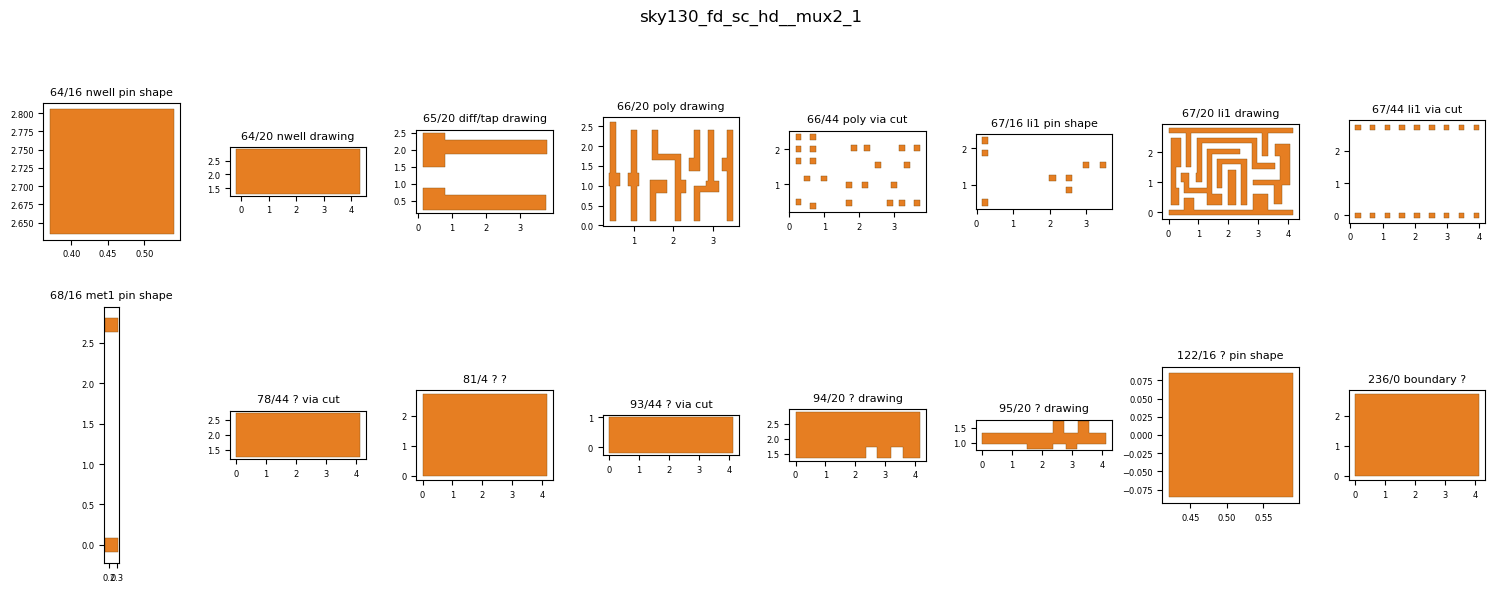

In [7]:
keys = sorted({(p.layer, p.datatype) for p in mux.polygons})
fig, axes = plt.subplots(2, (len(keys) + 1) // 2, figsize=(15, 6))
for ax, k in zip(axes.flat, keys):
    ax.add_collection(PolyCollection([p.points for p in mux.polygons if (p.layer, p.datatype) == k],
                                     facecolors='#e67e22', edgecolors='#7f4f10', linewidths=0.3))
    ax.autoscale(); ax.set_aspect('equal'); ax.tick_params(labelsize=6)
    ax.set_title(f'{k[0]}/{k[1]} {LAYERS.get(k[0], "?")} {DT.get(k[1], "?")}', fontsize=8)
for ax in axes.flat[len(keys):]: ax.set_axis_off()
fig.suptitle(mux.name); plt.tight_layout(); plt.show()

In [8]:
ZS = 6.0
STACK = {
    (65, 20): ('diff',  0.00, 0.12, '#4a7c59'),
    (66, 20): ('poly',  0.14, 0.43, '#c0392b'),
    (66, 44): ('licon', 0.43, 0.94, '#95a5a6'),
    (67, 20): ('li1',   0.94, 1.04, '#c9a227'),
    (67, 44): ('mcon',  1.04, 1.38, '#e67e22'),
    (68, 20): ('met1',  1.38, 1.74, '#3498db'),
    (68, 44): ('via1',  1.74, 2.01, '#e67e22'),
    (69, 20): ('met2',  2.01, 2.37, '#9b59b6'),
    (69, 44): ('via2',  2.37, 2.79, '#e67e22'),
    (70, 20): ('met3',  2.79, 3.63, '#1abc9c'),
    (70, 44): ('via3',  3.63, 4.02, '#e67e22'),
    (71, 20): ('met4',  4.02, 4.87, '#e84393'),
    (71, 44): ('via4',  4.87, 5.37, '#e67e22'),
    (72, 20): ('met5',  5.37, 6.63, '#576574'),
}

def triangulate(pts):
    if len(pts) == 4:
        return np.array([(0, 1, 2), (0, 2, 3)], np.uint32)
    return mapbox_earcut.triangulate_float64(np.asarray(pts, np.float64),
                                             np.array([len(pts)], np.uint32)).reshape(-1, 3)

def prism_mesh(polys, zlo, zhi):
    V, F = [], []
    for pts in polys:
        n, base = len(pts), len(V)
        V += [(x, y, zlo * ZS) for x, y in pts] + [(x, y, zhi * ZS) for x, y in pts]
        for a, b, c in triangulate(pts):
            F += [(base + a, base + c, base + b), (base + n + a, base + n + b, base + n + c)]
        for i in range(n):
            j = (i + 1) % n
            F += [(base + i, base + j, base + n + j), (base + i, base + n + j, base + n + i)]
    return np.array(V, np.float32), np.array(F, np.uint32)

def scene(peels=4):
    p = k3d.plot(grid_visible=False, background_color=0x111111, axes_helper=0,
                 camera_rotate_speed=3.0, logarithmic_depth_buffer=False, depth_peels=peels)
    p.colorbar_object_id = 0
    return p

def show3d(plot, title, fname, height=700):
    plot += k3d.text2d(f'<span style="color:#eee;font-family:sans-serif">{title}</span>',
                       position=[0.01, 0.01], is_html=True, label_box=False)
    plot.snapshot_type = 'full'
    os.makedirs('figs', exist_ok=True)
    guard = ('<script>try{var _c=document.createElement("canvas"),_g=_c.getContext("webgl2");'
             'if(_g){var _l=_g.getExtension("WEBGL_lose_context");if(_l)_l.loseContext();}'
             'else{document.addEventListener("DOMContentLoaded",function(){'
             'document.body.innerHTML=\'<div style="color:#9aa4b0;background:#111;'
             'position:absolute;inset:0;display:flex;align-items:center;justify-content:center;'
             'font-family:sans-serif;font-size:15px">This figure needs WebGL2 (try Chrome).'
             '</div>\';});}}catch(e){}</script>')
    snap = plot.get_snapshot(compression_level=9).replace('<body>', '<body>' + guard, 1)
    open(f'figs/{fname}.html', 'w').write(snap)
    display({'text/html': f'<iframe src="figs/{fname}.html" loading="lazy" '
             f'style="width:100%;height:{height}px;border:0;background:#111"></iframe>'}, raw=True)

def add_gates(plot, top, region=None, zlo=-0.30, zhi=0.135):
    boxes = defaultdict(list)
    for r in top.references:
        (x0, y0), (x1, y1) = r.bounding_box()
        if region:
            x0, y0 = max(x0, region[0]), max(y0, region[1])
            x1, y1 = min(x1, region[2]), min(y1, region[3])
            if x0 >= x1 or y0 >= y1: continue
        boxes[r.cell.name.split('__')[-1]].append([(x0, y0), (x1, y0), (x1, y1), (x0, y1)])
    (x0, y0), (x1, y1) = ((region[0], region[1]), (region[2], region[3])) if region \
        else top.bounding_box()
    V, F = prism_mesh([[(x0, y0), (x1, y0), (x1, y1), (x0, y1)]], zlo - 0.01, zhi - 0.003)
    plot += k3d.mesh(V, F, color=0x3d4852, opacity=0.4, flat_shading=True, name='substrate')
    for i, (cn, polys) in enumerate(sorted(boxes.items(), key=lambda b: -len(b[1]))):
        cr, cg, cb, _ = plt.cm.tab20(i % 20)
        V, F = prism_mesh(polys, zlo, zhi)
        plot += k3d.mesh(V, F, color=(int(cr * 255) << 16) + (int(cg * 255) << 8) + int(cb * 255),
                         opacity=0.5, flat_shading=True, name=f'cell {cn} ({len(polys)})')

def rect_clip(pts, x0, y0, x1, y1):
    for axis, lim, sgn in ((0, x0, 1), (0, x1, -1), (1, y0, 1), (1, y1, -1)):
        kept = []
        for i in range(len(pts)):
            a, b = pts[i - 1], pts[i]
            da, db = sgn * (a[axis] - lim), sgn * (b[axis] - lim)
            if (da >= 0) != (db >= 0):
                t = da / (da - db)
                kept.append((a[0] + t * (b[0] - a[0]), a[1] + t * (b[1] - a[1])))
            if db >= 0: kept.append((b[0], b[1]))
        pts = kept
        if len(pts) < 3: return None
    return pts

def fig3d(top, fname, region=None, title='', height=700):
    groups = defaultdict(list)
    for p in top.get_polygons(depth=None):
        if (p.layer, p.datatype) not in STACK: continue
        pts = p.points
        if region:
            x0, y0, x1, y1 = region
            if STACK[(p.layer, p.datatype)][0] in ('licon', 'mcon', 'via1', 'via2', 'via3', 'via4'):
                x0, y0, x1, y1 = x0 + 0.5, y0 + 0.5, x1 - 0.5, y1 - 0.5
            pts = rect_clip(pts, x0, y0, x1, y1)
            if pts is None: continue
        groups[STACK[(p.layer, p.datatype)]].append(pts)
    plot = scene()
    for (name, zlo, zhi, color), polys in sorted(groups.items(), key=lambda g: g[0][1]):
        parts = [(name, zlo, polys)]
        if name == 'licon':
            ctr = np.array([np.mean(p, axis=0) for p in polys])
            on = np.zeros(len(polys), bool)
            for g in groups.get(STACK[(66, 20)], []):
                (gx0, gy0), (gx1, gy1) = np.min(g, 0), np.max(g, 0)
                m = (ctr[:, 0] >= gx0) & (ctr[:, 0] <= gx1) \
                    & (ctr[:, 1] >= gy0) & (ctr[:, 1] <= gy1)
                if m.any(): on[np.flatnonzero(m)[Path(g).contains_points(ctr[m])]] = True
            parts = [(f'{name} on poly', zlo, [p for p, k in zip(polys, on) if k]),
                     (f'{name} on diff', STACK[(65, 20)][2], [p for p, k in zip(polys, on) if not k])]
        for pname, pzlo, ppolys in parts:
            if not ppolys: continue
            V, F = prism_mesh(ppolys, pzlo, zhi)
            plot += k3d.mesh(V, F, color=int(color[1:], 16), flat_shading=True,
                             name=f'{pname} ({len(ppolys)})')
    add_gates(plot, top, region)
    return show3d(plot, title, fname, height)

fig3d(mux, 'mux3d', title=mux.name + ' in 3D (K3D panel &#9656; Objects toggles layers)')

In [9]:
fig3d(warmup, 'warmup3d', title='The warm-up GDS, full stack (colored slabs below mark placed cells by type)')

## The puzzle

We repeat the same inspection on the real die.

In [10]:
plib = gdstk.read_gds('repo/puzzle.gds')
puzzle = plib.top_level()[0]
ppolys = puzzle.get_polygons(depth=None)
print(len(plib.cells), 'cells | top:', puzzle.name, '|', len(puzzle.references),
      'refs |', len(ppolys), 'polygons')
wkeys = {(p.layer, p.datatype) for p in wpolys}
pkeys = {(p.layer, p.datatype) for p in ppolys}
print('layers also in warmup:', sorted(pkeys & wkeys))
print('layers only here:     ', sorted(pkeys - wkeys))

81 cells | top: puzzle | 9875 refs | 130137 polygons
layers also in warmup: [(64, 16), (64, 20), (65, 20), (65, 44), (66, 20), (66, 44), (67, 16), (67, 20), (67, 44), (68, 16), (68, 20), (68, 44), (69, 20), (69, 44), (70, 16), (70, 20), (70, 44), (71, 16), (71, 20), (71, 44), (72, 16), (72, 20), (78, 44), (81, 4), (93, 44), (94, 20), (95, 20), (122, 16), (235, 4), (236, 0)]
layers only here:      [(66, 15), (81, 23), (200, 0)]


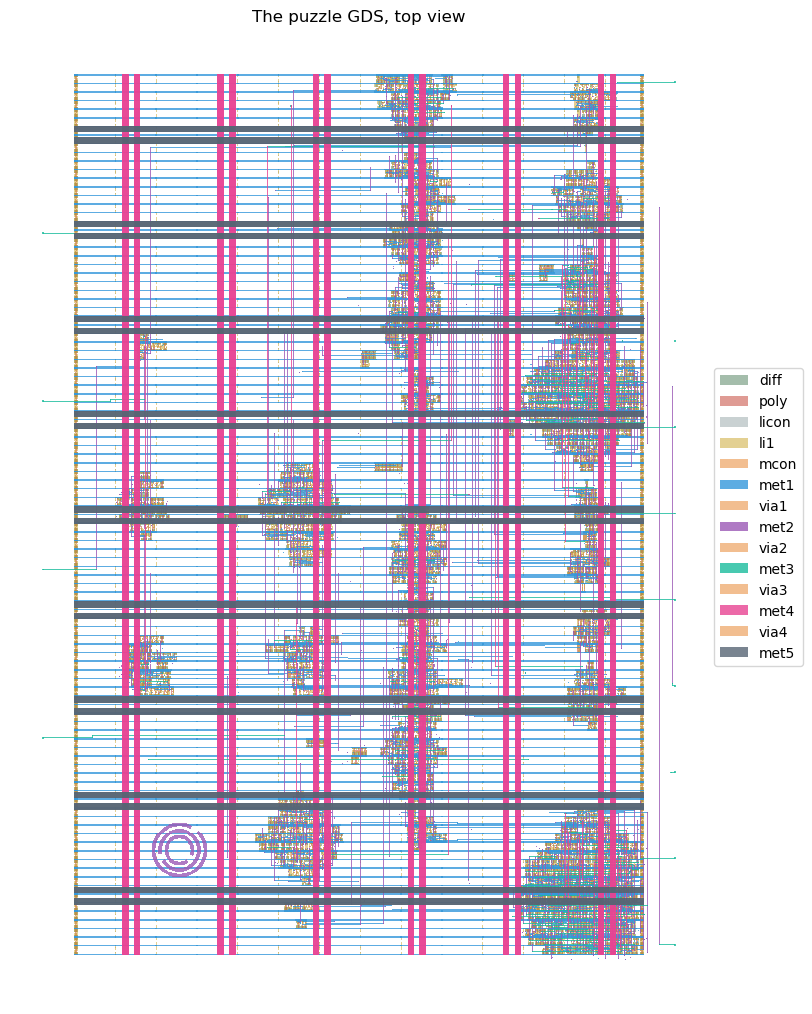

In [11]:
groups = defaultdict(list)
for p in ppolys:
    if (p.layer, p.datatype) in STACK:
        groups[STACK[(p.layer, p.datatype)]].append(p.points)
fig, ax = plt.subplots(figsize=(9, 13))
for (name, zlo, zhi, color), polys in sorted(groups.items(), key=lambda g: g[0][1]):
    ax.add_collection(PolyCollection(polys, facecolors=color, linewidths=0,
                                     alpha=0.8 if name.startswith('met') else 0.5, label=name))
ax.autoscale(); ax.set_aspect('equal'); ax.set_axis_off()
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
ax.set_title('The puzzle GDS, top view')
plt.show()

In [12]:
cx, cy = np.median([r.origin for r in puzzle.references], axis=0)
fig3d(puzzle, 'puzzle_zoom3d', region=(cx - 15, cy - 12, cx + 15, cy + 12),
      title='The puzzle GDS, a 30x24um zoom, full stack (cell footprints below)')

## From GDS geometry to wires

A net is a connected component of geometry: polygons that touch on the same conductor layer are in electrical contact, and a via cut joins the conductors it meets on adjacent layers. Shapely finds the contacts; a disjoint-set union merges them.

In [13]:
a = shapely.box(0, 0, 2, 1)
b = shapely.box(1.5, 0, 3, 1)
c = shapely.box(5, 5, 6, 6)
print(a.intersects(b), a.intersects(c))
tree = STRtree([a, b, c])
print(tree.query([a, b, c], predicate='intersects'))

True False
[[0 0 1 1 2]
 [0 1 0 1 2]]


In [14]:
CONDL = {67: 'li1', 68: 'met1', 69: 'met2', 70: 'met3', 71: 'met4', 72: 'met5'}

def flatten_metal(top):
    cond = {L: [] for L in CONDL}
    vias = {L: [] for L in range(67, 72)}
    for p in top.get_polygons(depth=None):
        if p.layer in CONDL and p.datatype in (20, 16):
            cond[p.layer].append(p.points)
        elif p.datatype == 44 and 67 <= p.layer <= 71:
            vias[p.layer].append(p.points)
    return cond, vias

wcond, wvias = flatten_metal(warmup)
pcond, pvias = flatten_metal(puzzle)
for name, cond, vias in [('warmup', wcond, wvias), ('puzzle', pcond, pvias)]:
    print(name, {CONDL[L]: len(v) for L, v in cond.items()},
          'via cuts', sum(len(v) for v in vias.values()))

warmup {'li1': 2393, 'met1': 2118, 'met2': 2104, 'met3': 331, 'met4': 111, 'met5': 28} via cuts 4294
puzzle {'li1': 19337, 'met1': 17654, 'met2': 8517, 'met3': 2560, 'met4': 867, 'met5': 162} via cuts 33323


The whole die at once: everything first, then only the conductors.

In [15]:
fig3d(puzzle, 'puzzle3d', title='The puzzle GDS, whole die, full stack', height=750)

In [16]:
plot = scene(peels=0)
for L in CONDL:
    name, zlo, zhi, color = STACK[(L, 20)]
    V, F = prism_mesh(pcond[L], zlo, zhi)
    plot += k3d.mesh(V, F, color=int(color[1:], 16), flat_shading=True,
                     name=f'{name} ({len(pcond[L])})')
for L in range(67, 72):
    name, zlo, zhi, color = STACK[(L, 44)]
    V, F = prism_mesh(pvias[L], zlo, zhi)
    plot += k3d.mesh(V, F, color=int(color[1:], 16), flat_shading=True,
                     name=f'{name} ({len(pvias[L])} cuts)')
show3d(plot, 'The puzzle, conductors only', 'puzzle_conductors', height=750)

In [17]:
class DSU:
    def __init__(s, n): s.p = list(range(n))
    def find(s, a):
        r = a
        while s.p[r] != r: r = s.p[r]
        while s.p[a] != r: s.p[a], a = r, s.p[a]
        return r
    def union(s, a, b):
        ra, rb = s.find(a), s.find(b)
        if ra != rb: s.p[rb] = ra

li = [shapely.Polygon(pts) for pts in wcond[67]]
d = DSU(len(li))
for i, j in zip(*STRtree(li).query(li, predicate='intersects')):
    d.union(int(i), int(j))
print(len(li), 'li1 polygons ->', len({d.find(i) for i in range(len(li))}), 'groups on li1 alone')

2393 li1 polygons -> 863 groups on li1 alone


In [18]:
def extract_nets(cond, vias):
    geoms, offset, n = {}, {}, 0
    for L in CONDL:
        offset[L] = n
        geoms[L] = [shapely.Polygon(pts) for pts in cond[L]]
        n += len(geoms[L])
    dsu = DSU(n)
    trees = {L: STRtree(geoms[L]) for L in CONDL if geoms[L]}
    for L in CONDL:
        if not geoms[L]: continue
        for i, j in zip(*trees[L].query(geoms[L], predicate='intersects')):
            dsu.union(offset[L] + int(i), offset[L] + int(j))
    for L, cuts in vias.items():
        if not (geoms.get(L) and geoms.get(L + 1)): continue
        cut_geoms = [shapely.Polygon(pts) for pts in cuts]
        touch = defaultdict(list)
        for c, g in zip(*trees[L].query(cut_geoms, predicate='intersects')):
            touch[int(c)].append(offset[L] + int(g))
        for c, g in zip(*trees[L + 1].query(cut_geoms, predicate='intersects')):
            touch[int(c)].append(offset[L + 1] + int(g))
        for members in touch.values():
            for m in members[1:]: dsu.union(members[0], m)
    rep = [(L, g) for L in CONDL for g in geoms[L]]
    net_id = {p: k for k, p in enumerate({rep[dsu.find(i)] for i in range(n)})}
    net_of = [net_id[rep[dsu.find(i)]] for i in range(n)]
    return geoms, offset, trees, net_of, len(net_id)

wg, wo, wt, wnet, wN = extract_nets(wcond, wvias)
pg, po, pt, pnet, pN = extract_nets(pcond, pvias)
print(f'warmup: {sum(len(g) for g in wg.values())} metal polygons -> {wN} nets')
print(f'puzzle: {sum(len(g) for g in pg.values())} metal polygons -> {pN} nets')

warmup: 7085 metal polygons -> 335 nets
puzzle: 49097 metal polygons -> 2626 nets


62 nets span exactly li1+met1+met2; inspecting net 72 (20 polygons)
via cuts on it: {'li1-met1': 2, 'met1-met2': 2}


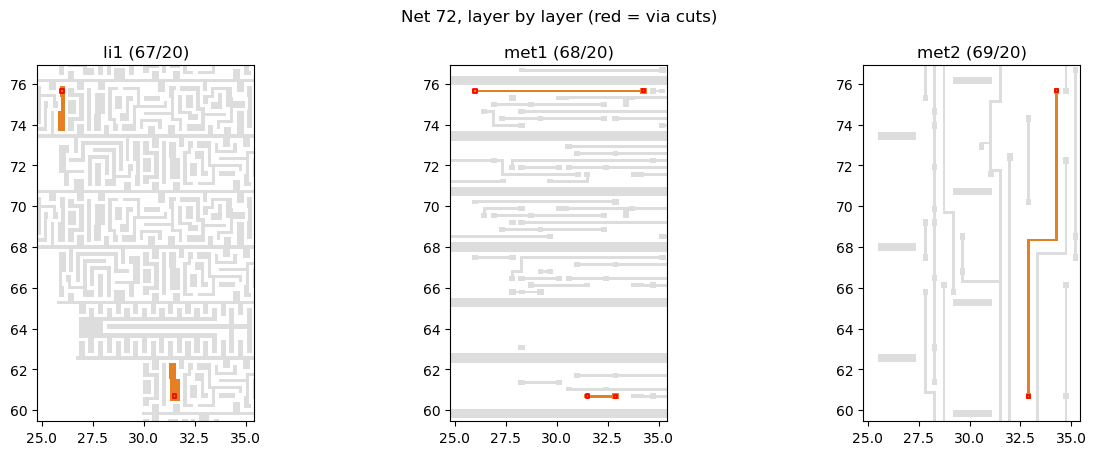

In [19]:
span, size = defaultdict(set), Counter()
for L in CONDL:
    for idx in range(len(wg[L])):
        net = wnet[wo[L] + idx]
        span[net].add(L); size[net] += 1
cand = sorted(n for n in span if span[n] == {67, 68, 69})
pick = sorted(cand, key=lambda n: size[n])[len(cand) // 2]
print(f'{len(cand)} nets span exactly li1+met1+met2; inspecting net {pick} '
      f'({size[pick]} polygons)')
picked_cuts = defaultdict(list)
for L, cs in wvias.items():
    for pts in cs:
        cg = shapely.Polygon(pts)
        hit = wt[L].query(cg, predicate='intersects')
        if len(hit) and wnet[wo[L] + int(hit[0])] == pick:
            picked_cuts[L].append(np.asarray(cg.exterior.coords))
print('via cuts on it:', {f'{CONDL[L]}-{CONDL[L + 1]}': len(v) for L, v in picked_cuts.items()})
allpts = [c for L in (67, 68, 69) for idx in range(len(wg[L]))
          if wnet[wo[L] + idx] == pick for c in wg[L][idx].exterior.coords]
x0, x1 = min(p[0] for p in allpts) - 1, max(p[0] for p in allpts) + 1
y0, y1 = min(p[1] for p in allpts) - 1, max(p[1] for p in allpts) + 1
fig, axes = plt.subplots(1, 3, figsize=(13, 4.6))
for ax, L in zip(axes, (67, 68, 69)):
    others, mine = [], []
    for idx, g in enumerate(wg[L]):
        pts = np.asarray(g.exterior.coords[:-1])
        if pts[:, 0].max() < x0 or pts[:, 0].min() > x1: continue
        if pts[:, 1].max() < y0 or pts[:, 1].min() > y1: continue
        (mine if wnet[wo[L] + idx] == pick else others).append(pts)
    ax.add_collection(PolyCollection(others, facecolors='#dddddd'))
    ax.add_collection(PolyCollection(mine, facecolors='#e67e22'))
    for LL in (L - 1, L):
        for cpts in picked_cuts.get(LL, []):
            ax.add_collection(PolyCollection([cpts], facecolors='none', edgecolors='red', linewidths=1.3))
    ax.set_xlim(x0, x1); ax.set_ylim(y0, y1); ax.set_aspect('equal')
    ax.set_title(f'{CONDL[L]} ({L}/20)')
fig.suptitle(f'Net {pick}, layer by layer (red = via cuts)')
plt.tight_layout(); plt.show()

The same net in 3D. The via plugs are what stitch the three layers into one wire.

In [20]:
plot = scene()
for L in (67, 68, 69):
    zlo, zhi = STACK[(L, 20)][1:3]
    others, mine = [], []
    for idx, g in enumerate(wg[L]):
        pts = np.asarray(g.exterior.coords[:-1])
        if pts[:, 0].max() < x0 or pts[:, 0].min() > x1: continue
        if pts[:, 1].max() < y0 or pts[:, 1].min() > y1: continue
        (mine if wnet[wo[L] + idx] == pick else others).append(pts)
    for polys, color, op, nm in ((others, 0x777777, 0.15, f'{CONDL[L]} others'),
                                 (mine, 0xe67e22, 1.0, f'{CONDL[L]} net {pick}')):
        if polys:
            V, F = prism_mesh(polys, zlo, zhi)
            plot += k3d.mesh(V, F, color=color, opacity=op, flat_shading=True, name=nm)
for L, cs in wvias.items():
    zlo, zhi = STACK[(L, 44)][1:3]
    mine, grays = [], []
    for pts in cs:
        if pts[:, 0].max() < x0 or pts[:, 0].min() > x1: continue
        if pts[:, 1].max() < y0 or pts[:, 1].min() > y1: continue
        cg = shapely.Polygon(pts)
        hit = wt[L].query(cg, predicate='intersects')
        (mine if len(hit) and wnet[wo[L] + int(hit[0])] == pick else grays).append(pts)
    if grays:
        V, F = prism_mesh(grays, zlo, zhi)
        plot += k3d.mesh(V, F, color=0x777777, opacity=0.15, flat_shading=True,
                         name=f'{STACK[(L, 44)][0]} others')
    if mine:
        V, F = prism_mesh(mine, zlo, zhi)
        plot += k3d.mesh(V, F, color=0xe67e22, flat_shading=True,
                         name=f'{STACK[(L, 44)][0]} on net {pick}')
cx, cy = (x0 + x1) / 2, (y0 + y1) / 2
D = max(x1 - x0, y1 - y0)
plot.camera_auto_fit = False
plot.camera = [cx + 0.55 * D, cy - 0.85 * D, 1.1 * D, cx, cy, 1.6 * ZS, 0, 0, 1]
show3d(plot, f'Net {pick} in 3D: one wire through the stack, neighbors dimmed', 'one_net', height=520)

In [21]:
def net_mesh(geoms, offset, net_of, keep=None, vias=None, trees=None):
    V, F, netv = [], [], []
    def emit(pts, zlo, zhi, net):
        n, base = len(pts), len(V)
        V.extend([(x, y, zlo * ZS) for x, y in pts] + [(x, y, zhi * ZS) for x, y in pts])
        netv.extend([net] * (2 * n))
        for a, b, c in triangulate(pts):
            F.extend([(base + a, base + c, base + b), (base + n + a, base + n + b, base + n + c)])
        for i in range(n):
            j = (i + 1) % n
            F.extend([(base + i, base + j, base + n + j), (base + i, base + n + j, base + n + i)])
    for L in CONDL:
        zlo, zhi = STACK[(L, 20)][1:3]
        for idx, g in enumerate(geoms[L]):
            net = net_of[offset[L] + idx]
            if keep is None or net in keep:
                emit(np.asarray(g.exterior.coords[:-1]), zlo, zhi, net)
    for L, cs in (vias or {}).items():
        zlo, zhi = STACK[(L, 44)][1:3]
        for pts in cs:
            hit = trees[L].query(shapely.Polygon(pts), predicate='intersects')
            if not len(hit): continue
            net = net_of[offset[L] + int(hit[0])]
            if keep is None or net in keep: emit(pts, zlo, zhi, net)
    return np.array(V, np.float32), np.array(F, np.uint32), np.array(netv, np.int64)

V, F, netv = net_mesh(wg, wo, wnet, vias=wvias, trees=wt)
plot = scene()
plot += k3d.mesh(V, F, attribute=((netv * 2654435761 % 4096) / 4096).astype(np.float32),
    color_map=k3d.colormaps.matplotlib_color_maps.hsv, color_range=[0, 1],
    flat_shading=True, name='nets')
add_gates(plot, warmup, zlo=0.60, zhi=0.95)

def pin_marker(plot, name, color, off=0.0, texts=None):
    lab = next(l for l in warmup.labels if l.text == name)
    x, y = float(lab.origin[0]), float(lab.origin[1])
    zp = STACK[(lab.layer, 20)][2] * ZS
    zt = STACK[(72, 20)][2] * ZS + 2.5 + off
    txt = name if texts is None else texts
    n = max(len(s) for s in ([txt] if isinstance(txt, str) else txt.values()))
    # texture_text squeezes text into a pow2 square canvas, so scale size with length
    size = 4.2 * 2 ** int(np.ceil(np.log2(max(48, 40.8 * n)))) / 68
    plot += k3d.line(np.array([[x, y, zp], [x, y, zt]], np.float32), color=color,
                     width=0.1, shader='simple', name=f'{name} leader')
    plot += k3d.texture_text(txt, position=[x, y, zt + 2.6],
                             color=color, size=size, font_weight=700, name=f'{name} label')

PINC = (('A', 0x3498db, 10), ('B', 0x3498db, 5), ('S', 0x2ecc71, 0),
        ('clk', 0x9aa5b1, 5), ('en', 0x9aa5b1, 0), ('rst_n', 0x9aa5b1, 0))
for pnm, pcol, poff in PINC:
    pin_marker(plot, pnm, pcol, poff)
plot.camera_auto_fit = False
plot.camera = [183.3, -150.0, 41.5, 50, 50, 28.2, 0, 0, 1]
show3d(plot, f'The warm-up, one color per net ({wN} nets); cells reach up to their li1 pins',
       'warmup_nets')

largest nets by polygon count: [(np.int64(2536), 8686), (np.int64(599), 8645), (np.int64(2099), 997), (np.int64(1672), 866), (np.int64(1377), 596)]


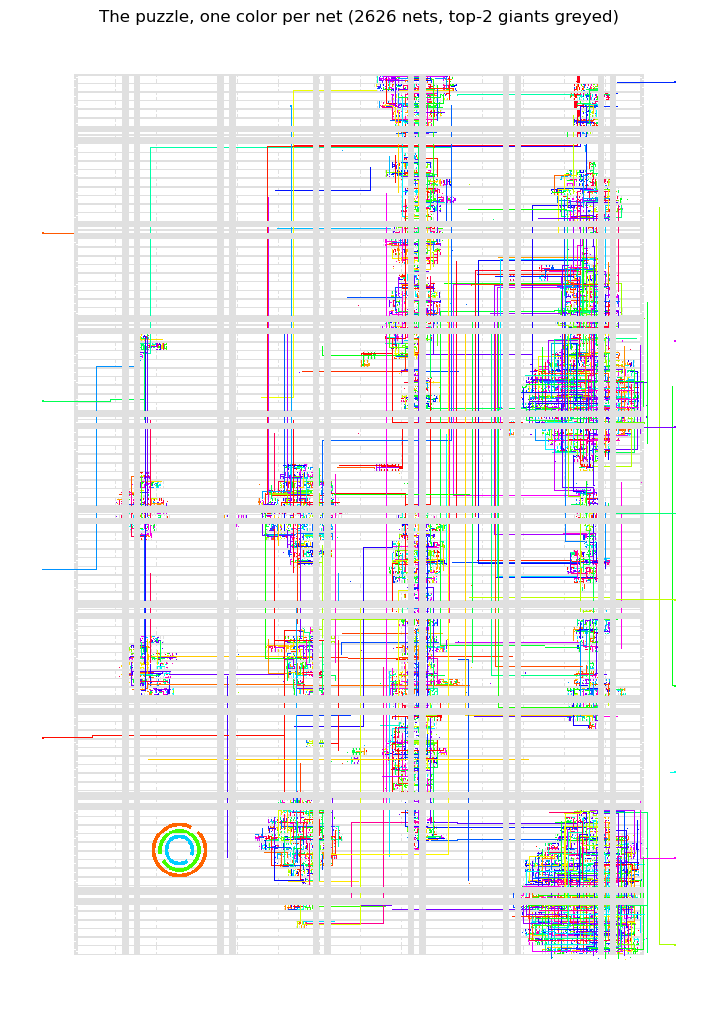

In [22]:
polys2d, nets2d = [], []
for L in CONDL:
    for idx, g in enumerate(pg[L]):
        polys2d.append(np.asarray(g.exterior.coords[:-1]))
        nets2d.append(pnet[po[L] + idx])
nets2d = np.array(nets2d)
psize = Counter(nets2d)
print('largest nets by polygon count:', psize.most_common(5))
power = {n for n, c in psize.most_common(2)}
colors = plt.cm.hsv((nets2d * 2654435761 % 4096) / 4096)
colors[np.isin(nets2d, list(power))] = (0.88, 0.88, 0.88, 1)
fig, ax = plt.subplots(figsize=(9, 13))
ax.add_collection(PolyCollection(polys2d, facecolors=colors, linewidths=0))
ax.autoscale(); ax.set_aspect('equal'); ax.set_axis_off()
ax.set_title(f'The puzzle, one color per net ({pN} nets, top-2 giants greyed)')
plt.show()

## Attaching names to components

GDS labels sit on the top-level ports; we pin them to our net IDs.

In [23]:
for l in warmup.labels:
    print(f'{l.text:>6} on {l.layer}/{l.texttype} at ({l.origin[0]:.2f}, {l.origin[1]:.2f})')

def net_at(pt, geoms, offset, trees, net_of, layer=67):
    hits = trees[layer].query(shapely.Point(pt), predicate='intersects')
    return net_of[offset[layer] + int(hits[0])] if len(hits) else None

def port_nets(top, geoms, offset, trees, net_of):
    return {l.text: net_at(l.origin, geoms, offset, trees, net_of, l.layer)
            for l in top.labels if l.texttype == 5 and l.layer in CONDL
            and l.text not in ('VPWR', 'VGND')}

wports = port_nets(warmup, wg, wo, wt, wnet)
pports = port_nets(puzzle, pg, po, pt, pnet)
print('warmup ports:', {k: f'n{v}' for k, v in wports.items()})

     A on 70/5 at (0.30, 41.14)
     B on 70/5 at (0.30, 35.70)
     S on 70/5 at (99.70, 16.66)
   clk on 70/5 at (0.30, 73.78)
    en on 70/5 at (0.30, 30.26)
 rst_n on 70/5 at (0.30, 57.46)
  VGND on 71/5 at (30.14, 50.32)
  VPWR on 71/5 at (26.44, 50.32)
  VGND on 72/5 at (49.91, 31.23)
  VPWR on 72/5 at (49.91, 27.53)
warmup ports: {'A': 'n161', 'B': 'n213', 'S': 'n215', 'clk': 'n297', 'en': 'n80', 'rst_n': 'n259'}


In [24]:
def xform(pt, ref):
    x, y = pt[0] * ref.magnification, pt[1] * ref.magnification
    if ref.x_reflection: y = -y
    c, s = np.cos(ref.rotation), np.sin(ref.rotation)
    return (ref.origin[0] + c * x - s * y, ref.origin[1] + s * x + c * y)

ref = next(r for r in warmup.references if 'mux2' in r.cell.name)
print(ref.cell.name, 'placed at', ref.origin, '| rotation', ref.rotation,
      '| reflected', ref.x_reflection)
for l in ref.cell.labels:
    if l.layer == 67 and l.texttype == 5:
        xy = xform(l.origin, ref)
        print(f'  {l.text:>5} label ({l.origin[0]:.2f}, {l.origin[1]:.2f}) -> ({xy[0]:.2f}, {xy[1]:.2f})'
              f' -> net n{net_at(xy, wg, wo, wt, wnet)}')

sky130_fd_sc_hd__mux2_1 placed at (25.76, 65.28) | rotation 0.0 | reflected False
      S label (3.46, 1.53) -> (29.22, 66.81) -> net n80
      S label (3.00, 1.53) -> (28.76, 66.81) -> net n80
     A1 label (2.54, 0.85) -> (28.30, 66.13) -> net n84
     A1 label (2.54, 1.19) -> (28.30, 66.47) -> net n84
     A0 label (2.08, 1.19) -> (27.84, 66.47) -> net n171
      X label (0.24, 0.51) -> (26.00, 65.79) -> net n219
      X label (0.24, 1.87) -> (26.00, 67.15) -> net n219
      X label (0.24, 2.21) -> (26.00, 67.49) -> net n219


We walk every placed cell and map its pins through the geometry to our nets. This gives the netlist: a list of placed cells together with the net attached to each of their pins.

In [25]:
PASSIVE = {'decap', 'tapvpwrvgnd', 'diode', 'fill'}

def short(master):
    return (master[len('sky130_fd_sc_hd__'):].rsplit('_', 1)[0]
            if master.startswith('sky130_fd_sc_hd__') else None)

def build_netlist(top, geoms, offset, trees, net_of):
    instances = []
    for r in top.references:
        sn = short(r.cell.name)
        if sn is None or sn in PASSIVE: continue
        pins = {}
        for l in r.cell.labels:
            if l.layer == 67 and l.texttype == 5 and l.text not in pins:
                pins[l.text] = net_at(xform(l.origin, r), geoms, offset, trees, net_of)
        assert None not in pins.values(), (r.cell.name, pins)
        instances.append((sn, pins, r))
    return instances

winst = build_netlist(warmup, wg, wo, wt, wnet)
pinst = build_netlist(puzzle, pg, po, pt, pnet)
print('warmup:', len(winst), 'logic instances', dict(Counter(sn for sn, p, r in winst)))
print('puzzle:', len(pinst), 'logic instances,', len({sn for sn, p, r in pinst}), 'distinct cell types')

warmup: 79 logic instances {'clkbuf': 3, 'and4bb': 2, 'and3': 1, 'mux2': 16, 'dfrtp': 16, 'a31o': 5, 'nor2': 8, 'a21boi': 1, 'o21bai': 1, 'and2': 7, 'xor2': 5, 'or2': 5, 'a21bo': 1, 'a21o': 1, 'nand2': 4, 'xnor2': 3}
puzzle: 728 logic instances, 64 distinct cell types


The warm-up also ships its routed DEF, which states the true connectivity. If our extraction is right, the two must agree exactly.

In [26]:
deftxt = open('repo/warmup/03_post_place_and_route.def').read()
defcomps = {}
for m in re.finditer(r'- (\S+) (\S+)(?: \+ SOURCE \S+)? \+ (?:FIXED|PLACED) \( (-?\d+) (-?\d+) \) (\w+)',
                     re.search(r'\nCOMPONENTS.*?\nEND COMPONENTS', deftxt, re.S).group()):
    defcomps[(m.group(2), round(int(m.group(3)) / 1000, 2), round(int(m.group(4)) / 1000, 2))] = m.group(1)
defnets = {}
for m in re.finditer(r'- (\S+)((?:\s+\( \S+ \S+ \))+)',
                     re.search(r'\nNETS.*?\nEND NETS', deftxt, re.S).group()):
    defnets[m.group(1).replace('\\', '')] = re.findall(r'\( (\S+) (\S+) \)', m.group(2))
print(len(defcomps), 'DEF components,', len(defnets), 'DEF nets,',
      sum(len(v) for v in defnets.values()), 'endpoints')

def site_ll(r):
    (x0, y0), (x1, y1) = r.cell.bounding_box()
    w, h = (x1 - x0) - 0.38, 2.72
    ox, oy = r.origin
    rot = round(r.rotation % (2 * np.pi), 3)
    if not r.x_reflection:
        return (ox, oy) if rot == 0 else (ox - w, oy - h)
    return (ox, oy - h) if rot == 0 else (ox - w, oy)

wnames = []
for sn, pins, r in winst:
    ll = site_ll(r)
    wnames.append(defcomps.get((r.cell.name, round(ll[0], 2), round(ll[1], 2))))
print('matched to DEF names:', sum(n is not None for n in wnames), 'of', len(winst))
i11 = wnames.index('sr_a/_11_')
for p, n in winst[i11][1].items():
    print(f'  sr_a/_11_.{p} -> n{n}')
print(f'endpoints on net {pick}:',
      [f'{wnames[i]}.{p}' for i, (sn, pins, r) in enumerate(winst)
       for p, n in pins.items() if n == pick])

230 DEF components, 84 DEF nets, 291 endpoints
matched to DEF names: 79 of 79
  sr_a/_11_.S -> n80
  sr_a/_11_.A1 -> n84
  sr_a/_11_.A0 -> n171
  sr_a/_11_.X -> n219
endpoints on net 72: ['sr_a/_15_.X', 'sr_a/_23_.D']


In [27]:
named = {wnames[i]: winst[i][1] for i in range(len(winst)) if wnames[i]}
intact, split, ours_of_def = 0, 0, {}
for dn, eps in defnets.items():
    got = {wports[p] if comp == 'PIN' else named[comp][p] for comp, p in eps}
    if len(got) == 1:
        intact += 1; ours_of_def[dn] = got.pop()
    else:
        split += 1; print('SPLIT', dn, got)
merged = len(ours_of_def) - len(set(ours_of_def.values()))
print(f'DEF nets matched 1:1 -> ours: {intact}/{len(defnets)}, split: {split}, merged: {merged}')

DEF nets matched 1:1 -> ours: 84/84, split: 0, merged: 0


That mux X pin's wire now has a name, `sr_a/_03_`. We follow it through the stack, from mux output to flip-flop input.

sr_a/_03_ is our net n219 - 17 polygons across ['li1', 'met1', 'met2']
endpoints: ['sr_a/_11_.X', 'sr_a/_19_.D']


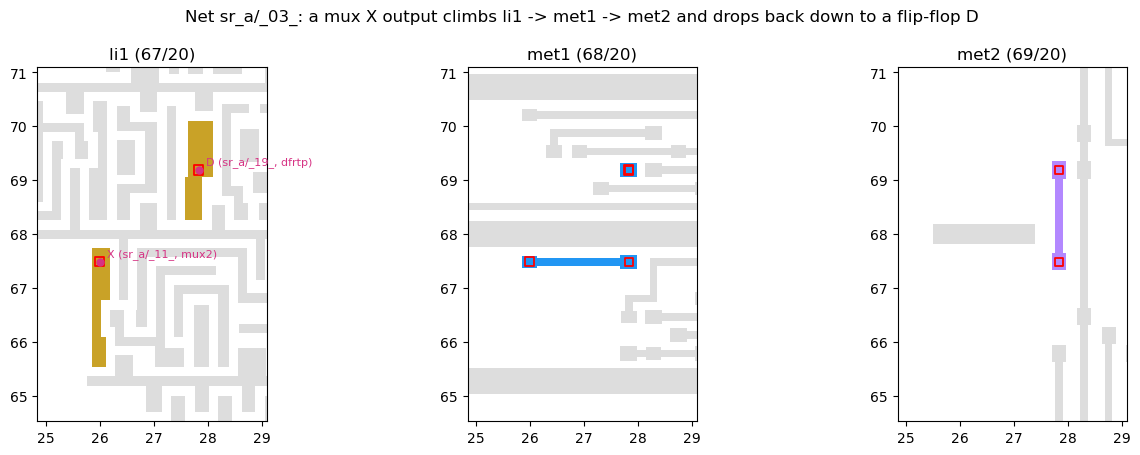

In [28]:
nd = ours_of_def['sr_a/_03_']
print('sr_a/_03_ is our net', f'n{nd} -', size[nd], 'polygons across',
      [CONDL[L] for L in sorted(span[nd])])
print('endpoints:', [f'{wnames[i]}.{p}' for i, (sn, pins, r) in enumerate(winst)
                     for p, n in pins.items() if n == nd])
nd_cuts = defaultdict(list)
for L, cs in wvias.items():
    for pts in cs:
        cg = shapely.Polygon(pts)
        hit = wt[L].query(cg, predicate='intersects')
        if len(hit) and wnet[wo[L] + int(hit[0])] == nd:
            nd_cuts[L].append(np.asarray(cg.exterior.coords))
epins = {}
for i, (sn, pins, r) in enumerate(winst):
    for l in r.cell.labels:
        if l.layer == 67 and l.texttype == 5 and pins.get(l.text) == nd:
            epins[f'{l.text} ({wnames[i]}, {sn})'] = xform(l.origin, r)
allpts = [c for L in (67, 68, 69) for idx in range(len(wg[L]))
          if wnet[wo[L] + idx] == nd for c in wg[L][idx].exterior.coords]
x0, x1 = min(p[0] for p in allpts) - 1, max(p[0] for p in allpts) + 1
y0, y1 = min(p[1] for p in allpts) - 1, max(p[1] for p in allpts) + 1
HL = {67: '#c9a227', 68: '#2196f3', 69: '#b388ff'}
fig, axes = plt.subplots(1, 3, figsize=(13, 4.6))
for ax, L in zip(axes, (67, 68, 69)):
    others, mine = [], []
    for idx, gm in enumerate(wg[L]):
        pts = np.asarray(gm.exterior.coords[:-1])
        if pts[:, 0].max() < x0 or pts[:, 0].min() > x1: continue
        if pts[:, 1].max() < y0 or pts[:, 1].min() > y1: continue
        (mine if wnet[wo[L] + idx] == nd else others).append(pts)
    ax.add_collection(PolyCollection(others, facecolors='#dddddd'))
    ax.add_collection(PolyCollection(mine, facecolors=HL[L]))
    for LL in (L - 1, L):
        for cpts in nd_cuts.get(LL, []):
            ax.add_collection(PolyCollection([cpts], facecolors='none', edgecolors='red', linewidths=1.3))
    if L == 67:
        for lab, (px, py) in epins.items():
            ax.plot(px, py, 'o', ms=5, color='#d63384')
            ax.annotate(lab, (px, py), textcoords='offset points',
                        xytext=(5, 4), fontsize=8, color='#d63384')
    ax.set_xlim(x0, x1); ax.set_ylim(y0, y1); ax.set_aspect('equal')
    ax.set_title(f'{CONDL[L]} ({L}/20)')
fig.suptitle('Net sr_a/_03_: a mux X output climbs li1 -> met1 -> met2 and drops back down to a flip-flop D')
plt.tight_layout(); plt.show()

In [29]:
print('puzzle ports:', {k: f'n{v}' for k, v in sorted(pports.items())})
for sn, c in Counter(sn for sn, p, r in pinst).most_common():
    print(f'  {sn:>8} x{c}')

puzzle ports: {'I': 'n1367', 'O[0]': 'n2595', 'O[1]': 'n168', 'O[2]': 'n1404', 'O[3]': 'n2173', 'O[4]': 'n377', 'O[5]': 'n856', 'O[6]': 'n779', 'O[7]': 'n40', 'clk': 'n431', 'enable': 'n1642', 'rst_n': 'n2099', 'success': 'n1794'}
     dfrtp x84
      nor2 x49
     nand2 x39
    clkbuf x32
      o21a x31
     and2b x30
     xnor2 x29
      a31o x26
      and3 x26
       inv x25
    nand2b x24
      a22o x23
      xor2 x21
      mux2 x21
     a21oi x20
      a21o x19
       or3 x18
      and2 x17
     nand4 x15
    and4bb x14
       or2 x13
     o211a x12
      o31a x11
       or4 x10
      or4b x9
      and4 x8
     o21ai x6
     a221o x6
      conb x6
     a211o x5
      a32o x5
     nor3b x5
    a21boi x4
     dfxtp x4
     and4b x4
      nor3 x4
     dfstp x4
      o22a x4
     and3b x4
      o32a x4
    a211oi x3
     o221a x3
     o21ba x2
     nand3 x2
      nor4 x2
     nor4b x2
     o311a x2
     o22ai x2
     a311o x2
     a21bo x2
     o31ai x2
   a2111oi x1
     a22oi x1
   

In [30]:
print(sorted({sn for sn, p, r in winst} | {sn for sn, p, r in pinst}))

['a2111oi', 'a211o', 'a211oi', 'a21bo', 'a21boi', 'a21o', 'a21oi', 'a221o', 'a221oi', 'a22o', 'a22oi', 'a311o', 'a31o', 'a31oi', 'a32o', 'a41oi', 'and2', 'and2b', 'and3', 'and3b', 'and4', 'and4b', 'and4bb', 'buf', 'clkbuf', 'conb', 'dfrtp', 'dfstp', 'dfxtp', 'inv', 'mux2', 'nand2', 'nand2b', 'nand3', 'nand3b', 'nand4', 'nor2', 'nor3', 'nor3b', 'nor4', 'nor4b', 'o211a', 'o211ai', 'o21a', 'o21ai', 'o21ba', 'o21bai', 'o221a', 'o22a', 'o22ai', 'o2bb2a', 'o311a', 'o31a', 'o31ai', 'o32a', 'o32ai', 'or2', 'or3', 'or3b', 'or4', 'or4b', 'or4bb', 'xnor2', 'xor2']


## From named cells to Boolean equations

Every SKY130 cell has a documented Boolean function. Substituting nets into each instance's rule gives an equation for every net and an update rule for every flip-flop.

In [31]:
CELL_FN = {
 'buf': {'X': 'A'}, 'clkbuf': {'X': 'A'}, 'inv': {'Y': '~A'},
 'and2': {'X': 'A&B'}, 'and2b': {'X': '~A_N&B'}, 'and3': {'X': 'A&B&C'}, 'and3b': {'X': '~A_N&B&C'},
 'and4': {'X': 'A&B&C&D'}, 'and4b': {'X': '~A_N&B&C&D'}, 'and4bb': {'X': '~A_N&~B_N&C&D'},
 'nand2': {'Y': '~(A&B)'}, 'nand2b': {'Y': '~(~A_N&B)'}, 'nand3': {'Y': '~(A&B&C)'},
 'nand3b': {'Y': '~(~A_N&B&C)'}, 'nand4': {'Y': '~(A&B&C&D)'},
 'nor2': {'Y': '~(A|B)'}, 'nor3': {'Y': '~(A|B|C)'}, 'nor3b': {'Y': '~(A|B|~C_N)'},
 'nor4': {'Y': '~(A|B|C|D)'}, 'nor4b': {'Y': '~(A|B|C|~D_N)'},
 'or2': {'X': 'A|B'}, 'or2b': {'X': 'A|~B_N'}, 'or3': {'X': 'A|B|C'}, 'or3b': {'X': 'A|B|~C_N'},
 'or4': {'X': 'A|B|C|D'}, 'or4b': {'X': 'A|B|C|~D_N'}, 'or4bb': {'X': 'A|B|~C_N|~D_N'},
 'xor2': {'X': 'A^B'}, 'xnor2': {'Y': '~(A^B)'}, 'mux2': {'X': '(S&A1)|(~S&A0)'},
 'a21o': {'X': '(A1&A2)|B1'}, 'a21oi': {'Y': '~((A1&A2)|B1)'},
 'a21bo': {'X': '(A1&A2)|~B1_N'}, 'a21boi': {'Y': '~((A1&A2)|~B1_N)'},
 'a211o': {'X': '(A1&A2)|B1|C1'}, 'a211oi': {'Y': '~((A1&A2)|B1|C1)'},
 'a2111oi': {'Y': '~((A1&A2)|B1|C1|D1)'},
 'a221o': {'X': '(A1&A2)|(B1&B2)|C1'}, 'a221oi': {'Y': '~((A1&A2)|(B1&B2)|C1)'},
 'a22o': {'X': '(A1&A2)|(B1&B2)'}, 'a22oi': {'Y': '~((A1&A2)|(B1&B2))'},
 'a311o': {'X': '(A1&A2&A3)|B1|C1'}, 'a31o': {'X': '(A1&A2&A3)|B1'},
 'a31oi': {'Y': '~((A1&A2&A3)|B1)'}, 'a32o': {'X': '(A1&A2&A3)|(B1&B2)'},
 'a41oi': {'Y': '~((A1&A2&A3&A4)|B1)'},
 'o21a': {'X': '(A1|A2)&B1'}, 'o21ai': {'Y': '~((A1|A2)&B1)'},
 'o211a': {'X': '(A1|A2)&B1&C1'}, 'o211ai': {'Y': '~((A1|A2)&B1&C1)'},
 'o21ba': {'X': '(A1|A2)&~B1_N'}, 'o21bai': {'Y': '~((A1|A2)&~B1_N)'},
 'o221a': {'X': '(A1|A2)&(B1|B2)&C1'}, 'o22a': {'X': '(A1|A2)&(B1|B2)'},
 'o22ai': {'Y': '~((A1|A2)&(B1|B2))'}, 'o2bb2a': {'X': '(~A1_N|~A2_N)&(B1|B2)'},
 'o311a': {'X': '(A1|A2|A3)&B1&C1'}, 'o31a': {'X': '(A1|A2|A3)&B1'},
 'o31ai': {'Y': '~((A1|A2|A3)&B1)'}, 'o32a': {'X': '(A1|A2|A3)&(B1|B2)'},
 'o32ai': {'Y': '~((A1|A2|A3)&(B1|B2))'}, 'conb': {'HI': '1', 'LO': '0'},
}
FF_RESET = {'dfrtp': ('RESET_B', 0), 'dfstp': ('SET_B', 1), 'dfxtp': (None, None)}

def build_logic(instances):
    eqs, ffs = {}, []
    for sn, pins, r in instances:
        if sn in CELL_FN:
            for out_pin, expr in CELL_FN[sn].items():
                if out_pin in pins:
                    ins = {p: n for p, n in pins.items() if p not in CELL_FN[sn]}
                    eqs[pins[out_pin]] = (expr, ins, sn)
        else:
            rpin, rval = FF_RESET[sn]
            ffs.append((pins['Q'], pins['D'], rval, pins.get(rpin), sn))
    return eqs, ffs

weqs, wffs = build_logic(winst)
peqs, pffs = build_logic(pinst)
print('warmup:', len(weqs), 'equations,', len(wffs), 'flip-flops',
      dict(Counter(sn for *_, sn in wffs)))
print('puzzle:', len(peqs), 'equations,', len(pffs), 'flip-flops',
      dict(Counter(sn for *_, sn in pffs)))

warmup: 63 equations, 16 flip-flops {'dfrtp': 16}
puzzle: 642 equations, 92 flip-flops {'dfrtp': 84, 'dfxtp': 4, 'dfstp': 4}


In [32]:
sn, pins, r = winst[i11]
rule = CELL_FN[sn]['X']
sub = re.sub(r'[A-Z][A-Z0-9_]*', lambda m: f'n{pins[m.group()]}', rule)
print(f'{sn}: X = {rule}')
print(f'sr_a/_11_: n{pins["X"]} = {sub}')
print('its select net is the en port:', pins['S'] == wports['en'])

mux2: X = (S&A1)|(~S&A0)
sr_a/_11_: n219 = (n80&n84)|(~n80&n171)
its select net is the en port: True


In [33]:
def namer(eqs, ffs, ports):
    names = {n: p for p, n in ports.items()}
    for i, (q, *_) in enumerate(ffs): names.setdefault(q, f'q{i}')
    return lambda n: names.get(n, f'n{n}')

def show_logic(eqs, ffs, ports, limit=None):
    nm = namer(eqs, ffs, ports)
    lines = [f'{nm(net):>7} = ' + re.sub(r'[A-Z][A-Z0-9_]*', lambda m: nm(ins[m.group()]), expr)
             + f'   [{sn}]' for net, (expr, ins, sn) in sorted(eqs.items())]
    lines += [f'{nm(q):>7} <= {nm(d)} @posedge clk' +
              (f', {rpin}=0 forces {rval}' if (rpin := {0: "RESET_B", 1: "SET_B"}.get(rval)) else '')
              for q, d, rval, rnet, sn in ffs]
    print(f'{len(eqs)} combinational equations, {len(ffs)} flip-flops')
    print('\n'.join(lines if limit is None else lines[:limit] + [f'... {len(lines) - limit} more']))

show_logic(weqs, wffs, wports)

63 combinational equations, 16 flip-flops
     n0 = (n173&n269)|~n75   [a21bo]
     n9 = n90^n199   [xor2]
    n41 = (en&q0)|(~en&q5)   [mux2]
    n46 = q11|q3   [or2]
    n47 = (en&q9)|(~en&q15)   [mux2]
    n56 = q9&q2   [and2]
    n70 = q9|q2   [or2]
    n72 = (en&q5)|(~en&q6)   [mux2]
    n73 = ~((n284&n87)|~n238)   [a21boi]
    n75 = ~(q11&q3)   [nand2]
    n81 = q10&q6   [and2]
    n87 = (n265&n237&n90)|n105   [a31o]
    n90 = ~(n94|n117)   [nor2]
    n94 = ~(q13|q0)   [nor2]
   n105 = (q15&q1&n227)|n117   [a31o]
   n111 = ~(q15|q1)   [nor2]
   n117 = q13&q0   [and2]
   n121 = ~(q9|q2)   [nor2]
   n125 = n184   [clkbuf]
   n126 = ~(n121|n56)   [nor2]
   n128 = (en&q15)|(~en&q13)   [mux2]
   n129 = q12&q7   [and2]
   n150 = (en&q7)|(~en&q3)   [mux2]
   n154 = n168&n304&n187   [and3]
   n168 = ~(n224^n87)   [xnor2]
   n173 = (q14&q4&n315)|n129   [a31o]
   n178 = n184   [clkbuf]
   n184 = clk   [clkbuf]
   n187 = ~((n202|n73)&~n81)   [o21bai]
   n193 = (en&q4)|(~en&q7)   [mux2]
   n

In [34]:
show_logic(peqs, pffs, pports, limit=25)

642 combinational equations, 92 flip-flops
     n0 = n2578|n1860|n1718   [or3]
     n1 = (n2401|n1707|n700)&n315   [o31a]
     n2 = (n1860&n2428)|(~n1860&n1412)   [mux2]
     n7 = ~(q71&q70)   [nand2]
    n13 = ~(n1071|n1678)   [nor2]
    n15 = (q84&n766)|q78   [a21o]
    n16 = ~n420&n840   [and2b]
    n23 = ~q15   [inv]
    n29 = ~(q40^q41)   [xnor2]
    n31 = n1503   [clkbuf]
    n33 = (q15|n1398)&n704   [o21a]
    n36 = ~((q76|n351)&(n1647|n1389))   [o22ai]
   O[7] = q0&n1&n520   [and3]
    n41 = ~(I&n1672&q14&n1467)   [nand4]
    n42 = (n1672&I)|(~n1672&q50)   [mux2]
    n47 = ~(q3|q6)   [nor2]
    n58 = ~(I&n1672&q16&n1270)   [nand4]
    n65 = ~(n2431|n1567)   [nor2]
    n69 = ~(~n332&n1829)   [nand2b]
    n77 = 1   [conb]
    n82 = (n1237&n1308)|(n775&n2460)   [a22o]
    n83 = ~((q4&q5)|q6)   [a21oi]
    n89 = ~(q4&n94)   [nand2]
    n92 = (q29|n1977)&n2178   [o21a]
    n94 = q3|q6   [or2]
... 709 more


## Simulation

We levelize the combinational nets, evaluate them in order, and clock the flip-flops.

In [35]:
class Sim:
    def __init__(s, eqs, ffs, ports, n_nets):
        s.ffs, s.ports, s.n = ffs, ports, n_nets
        s.compiled = {}
        for net, (expr, ins, sn) in eqs.items():
            args = sorted(ins)
            fn = eval('lambda ' + ','.join(args) + ': (' + expr + ')&1' if args
                      else 'lambda: (' + expr + ')&1')
            s.compiled[net] = (fn, [ins[a] for a in args])
        sources = {q for q, *_ in ffs} | set(ports.values())
        s.order, placed, remaining = [], set(sources), dict(eqs)
        while remaining:
            ready = [n for n, (e, ins, sn) in remaining.items()
                     if all(i in placed or i not in eqs for i in ins.values())]
            assert ready, 'combinational cycle'
            for n in ready:
                s.order.append(n); placed.add(n); remaining.pop(n)
        s.reset()
    def reset(s):
        s.val = [0] * s.n
        for q, d, rval, rnet, sn in s.ffs:
            if rval is not None: s.val[q] = rval
    def settle(s, inputs):
        for k, v in inputs.items():
            if k in s.ports: s.val[s.ports[k]] = v
        for n in s.order:
            fn, argnets = s.compiled[n]
            s.val[n] = fn(*[s.val[a] for a in argnets])
    def edge(s, inputs):
        s.settle(inputs)
        for q, v in [(q, s.val[d]) for q, d, *_ in s.ffs]: s.val[q] = v
        for q, d, rval, rnet, sn in s.ffs:
            if rnet is not None and s.val[rnet] == 0: s.val[q] = rval
        s.settle(inputs)

wsim = Sim(weqs, wffs, wports, wN)
psim = Sim(peqs, pffs, pports, pN)
print('combinational nets ordered without cycles:', len(wsim.order), 'warmup /', len(psim.order), 'puzzle')

combinational nets ordered without cycles: 63 warmup / 642 puzzle


Starting small, we shift a byte into `a_reg`.

In [36]:
areg = [ours_of_def[f'a_reg[{i}]'] for i in range(8)]
wsim.reset(); wsim.settle({'A': 0, 'B': 0, 'en': 0, 'rst_n': 0})
A = 0b10110010
print('feeding A =', format(A, '08b'), 'msb first')
for k in range(7, -1, -1):
    wsim.edge({'A': (A >> k) & 1, 'B': 0, 'en': 1, 'rst_n': 1})
    print(f'  edge {8 - k}: bit {(A >> k) & 1} -> a_reg[7:0] = '
          + ''.join(str(wsim.val[areg[i]]) for i in range(7, -1, -1)))

feeding A = 10110010 msb first
  edge 1: bit 1 -> a_reg[7:0] = 00000001
  edge 2: bit 0 -> a_reg[7:0] = 00000010
  edge 3: bit 1 -> a_reg[7:0] = 00000101
  edge 4: bit 1 -> a_reg[7:0] = 00001011
  edge 5: bit 0 -> a_reg[7:0] = 00010110
  edge 6: bit 0 -> a_reg[7:0] = 00101100
  edge 7: bit 1 -> a_reg[7:0] = 01011001
  edge 8: bit 0 -> a_reg[7:0] = 10110010


In [37]:
wstates, wlabels = [], []
wpairs = [(250, 246), (1, 2)]
for a, b in wpairs:
    wsim.reset()
    wsim.settle({'A': 0, 'B': 0, 'en': 0, 'rst_n': 0, 'clk': 0})
    print(f'\nA={a:08b} B={b:08b}  (A+B={a + b})')
    for i in range(7, -1, -1):
        inp = {'A': (a >> i) & 1, 'B': (b >> i) & 1, 'en': 1, 'rst_n': 1, 'clk': 0}
        wsim.settle(inp)
        wstates.append(np.array(wsim.val, np.uint8))
        wlabels.append(f'{a}+{b} e{8 - i} pre S={wsim.val[wports["S"]]}')
        wsim.edge(inp)
        wsim.settle({**inp, 'clk': 1})
        wstates.append(np.array(wsim.val, np.uint8))
        q = ''.join(str(wsim.val[qn]) for qn, *_ in wffs)
        S = wsim.val[wports['S']]
        print(f'  edge {8 - i}: in A={a >> i & 1} B={b >> i & 1}  ffs={q}  S={S}')
        wlabels.append(f'{a}+{b} e{8 - i} post S={S}')


A=11111010 B=11110110  (A+B=496)
  edge 1: in A=1 B=1  ffs=0000100000000010  S=0
  edge 2: in A=1 B=1  ffs=0000100100001010  S=0
  edge 3: in A=1 B=1  ffs=0001100100011010  S=0
  edge 4: in A=1 B=1  ffs=0011100101011010  S=0
  edge 5: in A=1 B=0  ffs=0111100101011001  S=0
  edge 6: in A=0 B=1  ffs=1111000101010111  S=0
  edge 7: in A=1 B=1  ffs=1111110011001111  S=0
  edge 8: in A=0 B=0  ffs=1110011110111101  S=1

A=00000001 B=00000010  (A+B=3)
  edge 1: in A=0 B=0  ffs=0000000000000000  S=0
  edge 2: in A=0 B=0  ffs=0000000000000000  S=0
  edge 3: in A=0 B=0  ffs=0000000000000000  S=0
  edge 4: in A=0 B=0  ffs=0000000000000000  S=0
  edge 5: in A=0 B=0  ffs=0000000000000000  S=0
  edge 6: in A=0 B=0  ffs=0000000000000000  S=0
  edge 7: in A=0 B=1  ffs=0000000000000010  S=0
  edge 8: in A=1 B=0  ffs=0000100000001000  S=0


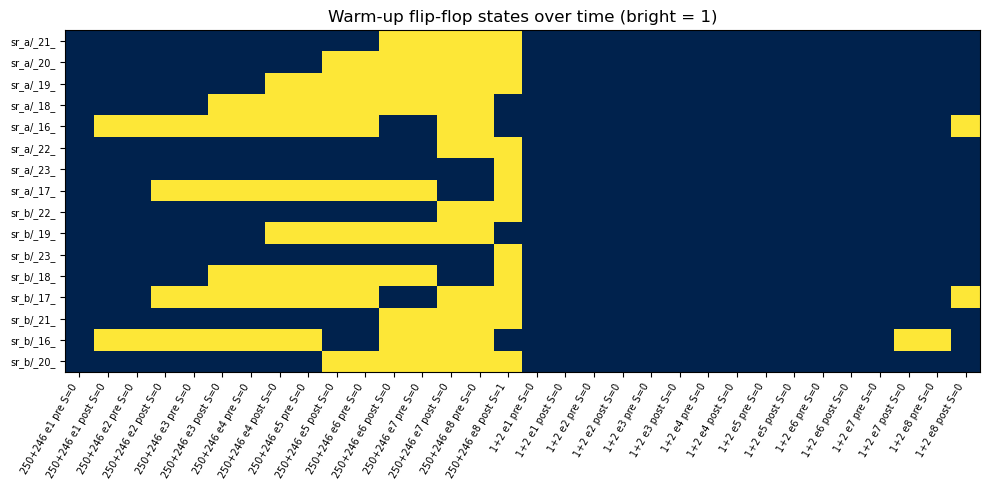

In [38]:
wffnames = [wnames[i] for i, (sn, p, r) in enumerate(winst) if sn in FF_RESET]
M = np.array([[st[q] for st in wstates] for q, *_ in wffs])
fig, ax = plt.subplots(figsize=(10, 5))
ax.imshow(M, cmap='cividis', aspect='auto', interpolation='nearest')
ax.set_yticks(range(len(wffnames)), wffnames, fontsize=7)
ax.set_xticks(range(len(wlabels)), wlabels, fontsize=7, rotation=60, ha='right')
ax.set_title('Warm-up flip-flop states over time (bright = 1)')
plt.tight_layout(); plt.show()

In [39]:
signal_w = set(weqs) | {q for q, *_ in wffs} | set(wports.values())
Vd, Fd, netd = net_mesh(wg, wo, wnet, signal_w, vias=wvias, trees=wt)
Vs, Fs, _ = net_mesh(wg, wo, wnet, set(range(wN)) - signal_w, vias=wvias, trees=wt)
plot = scene()
plot.time_interpolation = False
plot += k3d.mesh(Vs, Fs, color=0x333333, opacity=0.25, flat_shading=True, name='pwr/clk')
plot += k3d.mesh(Vd, Fd,
    attribute={str(t / 2): st[netd].astype(np.float32) for t, st in enumerate(wstates)},
    color_map=[0.0, 0.125, 0.19, 0.30, 1.0, 1.0, 0.83, 0.16], color_range=[0, 1],
    flat_shading=True, name='signal')
add_gates(plot, warmup, zlo=0.60, zhi=0.95)
def bit_label(nm, t):
    v = wpairs[t // 16]['AB'.index(nm)]
    k = t % 16 // 2
    s = format(v, '08b')
    return f'{nm}={v}=0b{s[:k]}[{s[k]}]{s[k + 1:]}'

for pnm, pcol, poff in PINC:
    pin_marker(plot, pnm, pcol, poff,
               {str(t / 2): bit_label(pnm, t) if pnm in 'AB'
                else f'{pnm}={int(st[wports[pnm]])}' for t, st in enumerate(wstates)})
plot.camera_auto_fit = False
plot.camera = [183.3, -150.0, 41.5, 50, 50, 28.2, 0, 0, 1]
plot.additional_js_code = f"""
var labs = {wlabels};
var d = document.body.appendChild(document.createElement('div'));
d.style.cssText = 'position:absolute;left:12px;bottom:12px;color:#ffd54a;' +
                  'font:15px monospace;pointer-events:none';
var hold = false;
function upd() {{
    var t = Math.min(labs.length - 1, Math.round(K3DInstance.parameters.time * 2));
    d.textContent = labs[t];
    if (t >= labs.length - 1 && !hold) {{
        hold = true;
        K3DInstance.stopAutoPlay();
        K3DInstance.setTime((labs.length - 1) / 2);
        setTimeout(function () {{
            hold = false;
            K3DInstance.setTime(0);
            K3DInstance.startAutoPlay();
        }}, 10000);
    }}
}}
K3DInstance.on(K3DInstance.events.TIME_CHANGE, upd);
upd();
K3DInstance.startAutoPlay();
"""
print(' | '.join(f'{t}={lab}' for t, lab in enumerate(wlabels)))
show3d(plot, 'The warm-up over time: yellow = net high, inputs settle pre-edge, flip-flops capture post-edge', 'warmup_replay')

0=250+246 e1 pre S=0 | 1=250+246 e1 post S=0 | 2=250+246 e2 pre S=0 | 3=250+246 e2 post S=0 | 4=250+246 e3 pre S=0 | 5=250+246 e3 post S=0 | 6=250+246 e4 pre S=0 | 7=250+246 e4 post S=0 | 8=250+246 e5 pre S=0 | 9=250+246 e5 post S=0 | 10=250+246 e6 pre S=0 | 11=250+246 e6 post S=0 | 12=250+246 e7 pre S=0 | 13=250+246 e7 post S=0 | 14=250+246 e8 pre S=0 | 15=250+246 e8 post S=1 | 16=1+2 e1 pre S=0 | 17=1+2 e1 post S=0 | 18=1+2 e2 pre S=0 | 19=1+2 e2 post S=0 | 20=1+2 e3 pre S=0 | 21=1+2 e3 post S=0 | 22=1+2 e4 pre S=0 | 23=1+2 e4 post S=0 | 24=1+2 e5 pre S=0 | 25=1+2 e5 post S=0 | 26=1+2 e6 pre S=0 | 27=1+2 e6 post S=0 | 28=1+2 e7 pre S=0 | 29=1+2 e7 post S=0 | 30=1+2 e8 pre S=0 | 31=1+2 e8 post S=0


## The example VCD

The repo ships `example_inputs.vcd`, real stimulus for the puzzle. We parse it and watch what `O` does before simulating anything.

In [40]:
def parse_vcd(path):
    ids, cur, edges = {}, {}, []
    in_defs = True
    for line in open(path):
        line = line.strip()
        if in_defs:
            if line.startswith('$var'): ids[line.split()[3]] = line.split()[4]
            if line.startswith('$enddefinitions'): in_defs = False
            continue
        if not line or line[0] in '$#': continue
        if line[0] == 'b':
            v, sym = line.split()
            v = v[1:]
        else:
            v, sym = line[0], line[1:]
        name = ids.get(sym)
        if name is None: continue
        val = None if 'x' in v or 'z' in v else int(v, 2)
        if name == 'clk' and cur.get('clk') == 0 and val == 1: edges.append(dict(cur))
        cur[name] = val
    return ids, edges

vids, edges = parse_vcd('repo/example_inputs.vcd')
print('vcd signals:', sorted(vids.values()))
print(len(edges), 'rising clk edges;',
      sum(1 for e in edges if e.get('enable') == 1 and e.get('rst_n') == 1), 'with enable=1')

vcd signals: ['I', 'O', 'clk', 'enable', 'rst_n', 'success']
312 rising clk edges; 242 with enable=1


In [41]:
raw = [e.get('O') or 0 for e in edges]
print('distinct O values in the vcd:', sorted(set(raw)))
print('as ascii:', ''.join(chr(v) if 32 <= v < 127 else '.' for v in raw))
print('success ever high in the vcd:', any(e.get('success') for e in edges))

distinct O values in the vcd: [0, 32, 65, 71, 73, 78, 82, 84, 89]
as ascii: .............................................................................................................................TRY AGAIN...................................................................................................................................................TRY AGAIN......................
success ever high in the vcd: False


We replay the VCD through our simulator; it must match on every edge.

In [42]:
psim.reset()
O = [pports[f'O[{i}]'] for i in range(8)]
pstates, prestates, rows = [], [], []
for e in edges:
    if e.get('rst_n') != 1:
        for q, d, rval, rnet, sn in psim.ffs:
            if rval is not None: psim.val[q] = rval
        psim.settle({'I': 0, 'enable': 0, 'rst_n': 0})
        continue
    inp = {'I': e.get('I') or 0, 'enable': e.get('enable') or 0, 'rst_n': 1, 'clk': 0}
    psim.settle(inp)
    prestates.append(np.array(psim.val, np.uint8))
    psim.edge(inp)
    psim.settle({**inp, 'clk': 1})
    pstates.append(np.array(psim.val, np.uint8))
    b = sum(psim.val[O[i]] << i for i in range(8))
    rows.append((e.get('I') or 0, e.get('enable') or 0, b, psim.val[pports['success']],
                 e.get('O'), e.get('success')))
print(len(pstates), 'edges after reset release')
print('input bits:', ''.join(str(i) for i, en, b, s, eo, es in rows if en))
print('our O:     ', ''.join(chr(b) if 32 <= b < 127 else '.' for i, en, b, s, eo, es in rows))
print('vcd O:     ', ''.join(chr(eo) if eo and 32 <= eo < 127 else '.' for i, en, b, s, eo, es in rows))
print('success mismatches vs vcd:', sum(1 for *_, s, eo, es in rows if es is not None and s != es),
      '| O mismatches vs vcd:', sum(1 for i, en, b, s, eo, es in rows if eo is not None and b != eo),
      '| success ever high:', any(s for *_, s, eo, es in rows))

306 edges after reset release
input bits: 00101010000000101100001010011000000000100000011101100001001011000011100110000000101100000010111000000000100000110011100001101011000010011110000000001000001000011000011101110000100001100001001011000000101110000110011100000000010000000000100000
our O:      ..........................................................................................................................TRY AGAIN................................................................................................................................................TRY AGAIN......................
vcd O:      ..........................................................................................................................TRY AGAIN................................................................................................................................................TRY AGAIN......................
success mismatches vs vcd: 0 | O mismatches vs vcd: 0 | success ever high: Fa

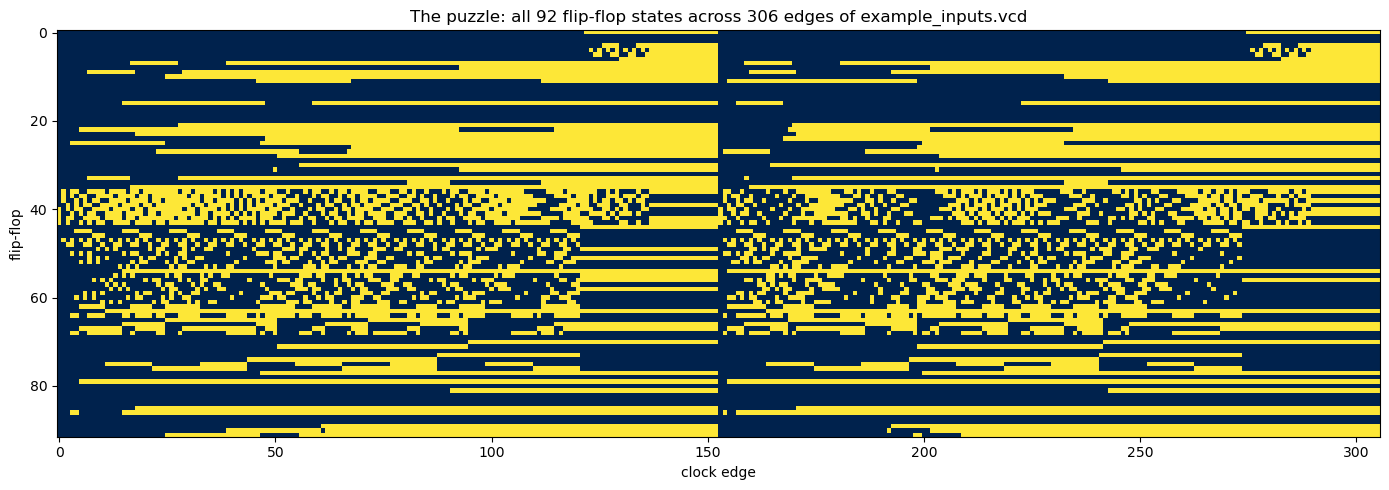

In [43]:
M = np.array([[st[q] for st in pstates] for q, *_ in pffs])
fig, ax = plt.subplots(figsize=(14, 5))
ax.imshow(M, cmap='cividis', aspect='auto', interpolation='nearest')
ax.set_xlabel('clock edge'); ax.set_ylabel('flip-flop')
ax.set_title(f'The puzzle: all {len(pffs)} flip-flop states across {len(pstates)} edges of example_inputs.vcd')
plt.tight_layout(); plt.show()

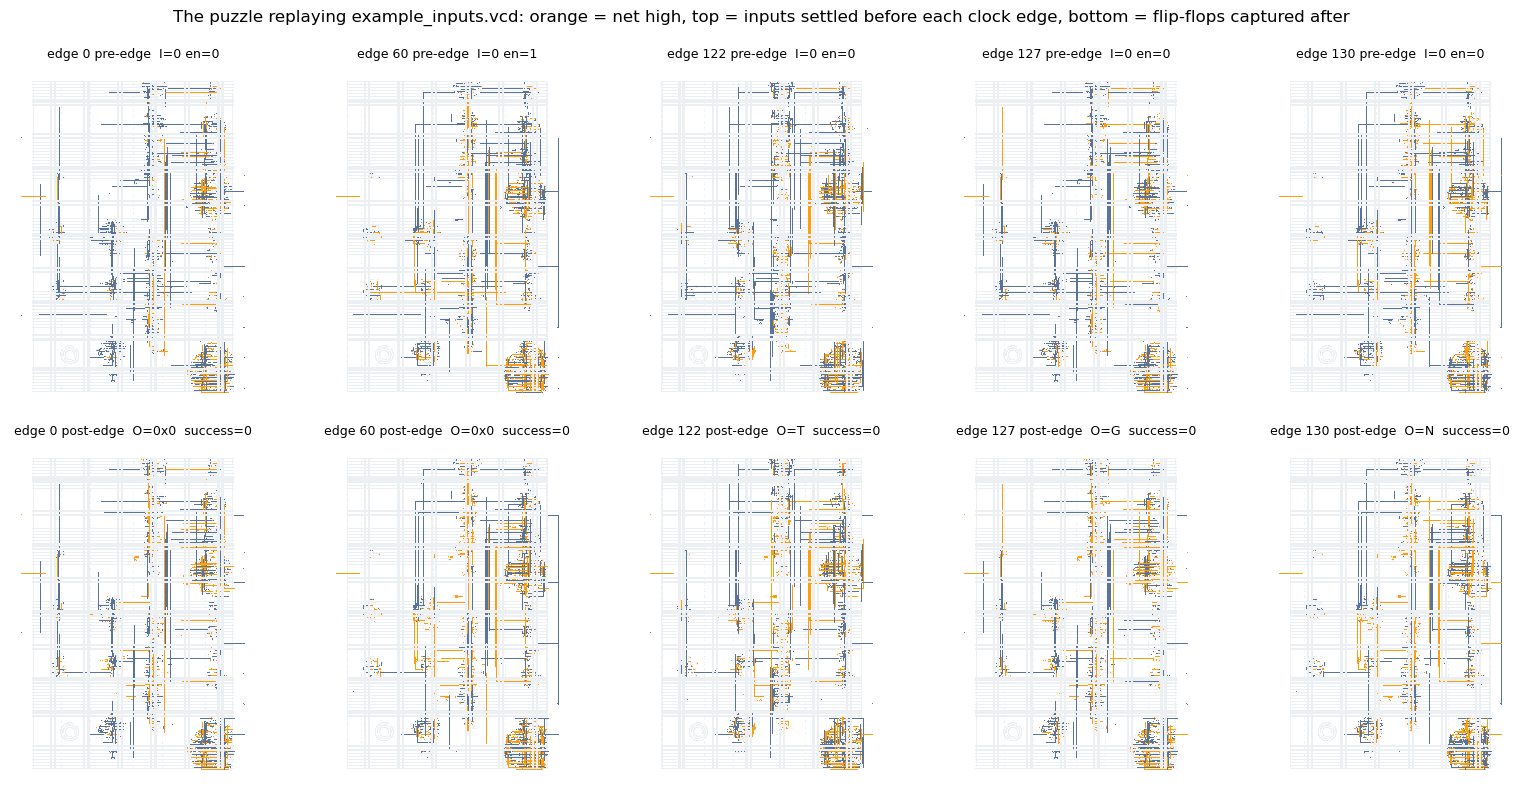

In [44]:
signal_p = set(peqs) | {q for q, *_ in pffs} | set(pports.values())
sigmask = np.isin(nets2d, list(signal_p))

def draw_state(st, title, ax):
    on = st[nets2d].astype(bool)
    colors = np.full((len(nets2d), 4), (0.93, 0.94, 0.95, 1.0))
    colors[sigmask & ~on] = (0.35, 0.45, 0.60, 1.0)
    colors[sigmask & on] = (1.00, 0.62, 0.05, 1.0)
    ax.add_collection(PolyCollection(polys2d, facecolors=colors, linewidths=0))
    ax.autoscale(); ax.set_aspect('equal'); ax.set_axis_off()
    ax.set_title(title, fontsize=9)

fig, axes = plt.subplots(2, 5, figsize=(16, 8))
for k, t in enumerate([0, 60, 122, 127, 130]):
    i, en, b, s, *_ = rows[t]
    draw_state(prestates[t], f'edge {t} pre-edge  I={i} en={en}', axes[0][k])
    draw_state(pstates[t], f'edge {t} post-edge  O={chr(b) if 32 <= b < 127 else hex(b)}  success={s}', axes[1][k])
fig.suptitle('The puzzle replaying example_inputs.vcd: orange = net high, '
             'top = inputs settled before each clock edge, bottom = flip-flops captured after', y=0.99)
plt.tight_layout(); plt.show()

The whole VCD replayed on the die. The `O` pins spell out the output.

In [45]:
import base64, json
allxy = np.concatenate(polys2d)
lo, span = allxy.min(0), allxy.max(0) - allxy.min(0)
qxy = np.round((allxy - lo) / span * 65535).astype('<u2')
cnt = np.array([len(p) for p in polys2d], '<u2')
frames = [st for pair in zip(prestates, pstates) for st in pair]
bits = np.packbits(np.array(frames, np.uint8).astype(bool), axis=1)
iseq = ''.join(str(int(st[pports['I']])) for st in frames[::2])
eseq = ''.join(str(int(st[pports['enable']])) for st in frames[::2])
def scan_runs(es):
    runs, s0 = {}, None
    for e, ch in enumerate(es + '0'):
        if ch == '1' and s0 is None: s0 = e
        elif ch != '1' and s0 is not None:
            for k in range(s0, e): runs[k] = (s0, e - s0)
            s0 = None
    return runs, max([1] + [-(-n // 64) for _, n in set(runs.values())])
runs, ILINES = scan_runs(eseq)
def iline(e):
    if e not in runs: return '\n'.join(['I=0'] + [''] * (ILINES - 1))
    a, n = runs[e]
    j, seq = e - a, iseq[a:a + n]
    out = []
    for k in range(0, n, 64):
        seg = seq[k:k + 64]
        if k <= j < k + 64:
            seg = seg[:j - k] + f'[{seg[j - k]}]' + seg[j - k + 1:]
        out.append(('I=0b' if k == 0 else '    ') + seg)
    out += [''] * (ILINES - len(out))
    return '\n'.join(out)
msg, pen, titles, olines = '', 1, [], []
for t, st in enumerate(frames):
    en, s = int(st[pports['enable']]), int(st[pports['success']])
    ck, rn = int(st[pports['clk']]), int(st[pports['rst_n']])
    b = sum(int(st[O[j]]) << j for j in range(8))
    if t % 2:
        if en and not pen: msg = ''
        if not en and 32 <= b < 127: msg += chr(b)
        pen = en
    titles.append(f'edge {t // 2} ' + ('post-edge' if t % 2 else 'pre-edge')
                  + f'\n{iline(t // 2)}\nen={en}\nclk={ck}\nrst_n={rn}\nsuccess={s}')
    olines.append(f'O=0b{b:08b}=0x{b:02x}' + (f"='{chr(b)}'" if 32 <= b < 127 else '')
                  + f'\ntext={msg}')
b64 = lambda a: base64.b64encode(np.ascontiguousarray(a).tobytes()).decode()
W = 640; H = int(W * span[1] / span[0]); LW = 104; XO = 64
c2 = allxy.mean(0)
lorig = {l.text: l.origin for l in puzzle.labels if l.layer == 70}
def pad_xy(text):
    x, y = lorig[text]
    return [float((x - lo[0]) / span[0] * W), float(H - (y - lo[1]) / span[1] * H)]
def spread(entries):
    entries.sort(key=lambda e: e[3])
    ys = [e[3] for e in entries]
    for i in range(1, len(ys)): ys[i] = max(ys[i], ys[i - 1] + 22)
    ys[-1] = min(ys[-1], H - 10)
    for i in range(len(ys) - 2, -1, -1): ys[i] = min(ys[i], ys[i + 1] - 22)
    for e, y in zip(entries, ys): e.append(float(max(y, 12)))
leg = [['success', int(pports['success'])] + pad_xy('success')]
leg += [[f'O{i}', int(O[i])] + pad_xy(f'O[{i}]') for i in range(8)]
spread(leg)
ileg = [[nm, int(pports[pk])] + pad_xy(pk)
        for nm, pk in (('I', 'I'), ('en', 'enable'), ('clk', 'clk'), ('rst_n', 'rst_n'))]
spread(ileg)
print(f'{len(polys2d)} polygons, {len(frames)} frames (pre+post per edge), '
      f'{(len(qxy.tobytes()) + len(bits.tobytes())) / 1e6:.1f}MB packed')
tpl = open('figs/viewer.html').read()
def fill(fbits, ftitles, folines, snet):
    return (tpl.replace('__XY__', b64(qxy)).replace('__CNT__', b64(cnt))
            .replace('__PNET__', b64(nets2d.astype('<u2'))).replace('__SIG__', b64(np.packbits(sigmask)))
            .replace('__BITS__', b64(fbits)).replace('__TITLES__', json.dumps(ftitles))
            .replace('__OLINES__', json.dumps(folines)).replace('__LEG__', json.dumps(leg))
            .replace('__ILEG__', json.dumps(ileg)).replace('__SNET__', str(snet))
            .replace('__MAXF__', str(fbits.shape[0] - 1)).replace('__BPF__', str(fbits.shape[1]))
            .replace('__W2__', str(2 * (XO + W + LW))).replace('__H2__', str(2 * H))
            .replace('__CW__', str(XO + W + LW)).replace('__XO__', str(XO))
            .replace('__W__', str(W)).replace('__H__', str(H)))
open('figs/replay.html', 'w').write(fill(bits, titles, olines, int(pports['success'])))
display({'text/html': f'<iframe src="figs/replay.html" loading="lazy" '
         f'style="width:100%;height:{H + 234 + 17 * (ILINES - 1)}px;border:0;background:#fff"></iframe>'}, raw=True)

49097 polygons, 612 frames (pre+post per edge), 1.3MB packed


92 flip-flops; 801 ff-to-ff dependencies
transitive fan-in of success: 79 flip-flops
the 4 reset-less dfxtp in that fan-in? []


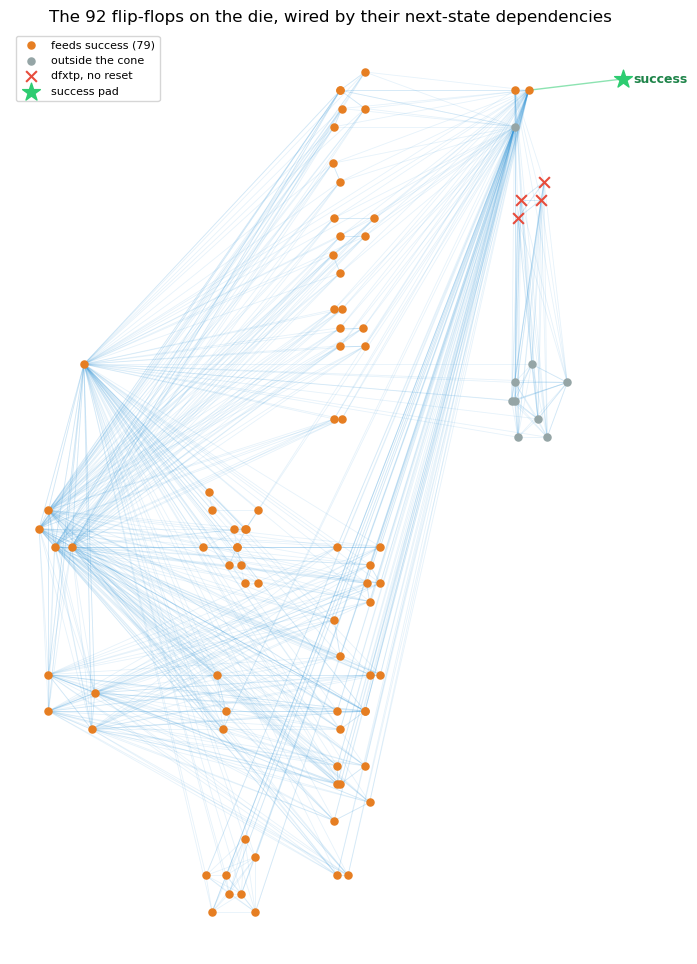

In [46]:
qidx = {q: i for i, (q, *_) in enumerate(pffs)}

def ff_sources(net):
    out, seen, stack = set(), set(), [net]
    while stack:
        n = stack.pop()
        if n in qidx: out.add(qidx[n]); continue
        if n in seen or n not in peqs: continue
        seen.add(n)
        stack += list(peqs[n][1].values())
    return out

deps = [ff_sources(d) for q, d, *_ in pffs]
cone, frontier = set(), ff_sources(pports['success'])
while frontier:
    cone |= frontier
    frontier = set().union(*(deps[i] for i in frontier)) - cone
dfx = {i for i, (q, d, rv, rn, sn) in enumerate(pffs) if sn == 'dfxtp'}
print(len(pffs), 'flip-flops;', sum(len(d) for d in deps), 'ff-to-ff dependencies')
print('transitive fan-in of success:', len(cone), 'flip-flops')
print('the', len(dfx), 'reset-less dfxtp in that fan-in?', sorted(dfx & cone))
pffpos = np.array([r.origin for sn, p, r in pinst if sn in FF_RESET])
fig, ax = plt.subplots(figsize=(9, 12))
for i, srcs in enumerate(deps):
    for jj in srcs:
        ax.plot(*zip(pffpos[jj], pffpos[i]), color='#3498db', alpha=0.12, lw=0.6, zorder=1)
incone = np.array([i in cone for i in range(len(pffs))])
isdfx = np.array([i in dfx for i in range(len(pffs))])
ax.scatter(*pffpos[incone].T, s=26, c='#e67e22', zorder=3, label=f'feeds success ({incone.sum()})')
ax.scatter(*pffpos[~incone & ~isdfx].T, s=26, c='#95a5a6', zorder=3, label='outside the cone')
ax.scatter(*pffpos[isdfx].T, s=60, c='#e74c3c', marker='x', zorder=4, label='dfxtp, no reset')
spts = np.concatenate([p for p, nn in zip(polys2d, nets2d) if nn == pports['success']])
sxy = spts[((spts - c2) ** 2).sum(1).argmax()]
for i in sorted(ff_sources(pports['success'])):
    ax.plot(*zip(pffpos[i], sxy), color='#2ecc71', alpha=0.55, lw=1.0, zorder=2)
ax.scatter(*sxy, s=180, c='#2ecc71', marker='*', zorder=5, label='success pad')
ax.annotate('success', sxy, textcoords='offset points', xytext=(8, -3),
            fontsize=9, color='#1e8449', fontweight='bold')
ax.set_aspect('equal'); ax.set_axis_off(); ax.legend(loc='upper left', fontsize=8)
ax.set_title('The 92 flip-flops on the die, wired by their next-state dependencies')
plt.show()

## Turning the clocked circuit into one finite formula

Each VCD attempt spans 122 edges: reset, 121 input bits, and an answer window. We give the state vector a separate name at each clock edge, connect adjacent states with the recovered update rules, and ask Z3 which input bits raise `success`.

vcd attempts as (enabled, disabled) edge counts: [[121, 32], [121, 32]]
so one attempt = 121 enabled edges -> unknowns I0..I120, states Q0..Q122


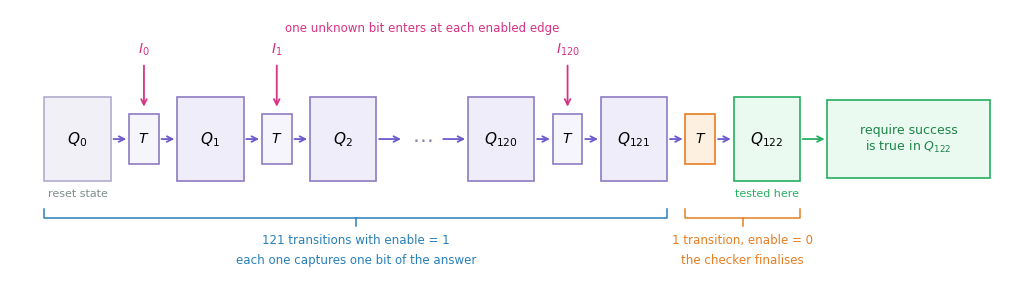

In [47]:
attempts, cur = [], None
for e in edges:
    if e.get('rst_n') != 1:
        cur = None; continue
    if cur is None:
        cur = [0, 0]; attempts.append(cur)
    cur[0 if e.get('enable') == 1 else 1] += 1
print('vcd attempts as (enabled, disabled) edge counts:', attempts)
n_en = attempts[0][0]
print(f'so one attempt = {n_en} enabled edges -> unknowns I0..I{n_en - 1}, states Q0..Q{n_en + 1}')
fig, ax = plt.subplots(figsize=(13, 3.6))

def qbox(x, nm, ec='#8e7cc3', fc='#f0edfa'):
    ax.add_patch(plt.Rectangle((x, 0.40), 0.58, 0.54, fc=fc, ec=ec, lw=1.2))
    ax.text(x + 0.29, 0.67, nm, ha='center', va='center', fontsize=11)

def tbox(x, ec='#8e7cc3', fc='#f7f5fc'):
    ax.add_patch(plt.Rectangle((x, 0.51), 0.26, 0.32, fc=fc, ec=ec, lw=1.2))
    ax.text(x + 0.13, 0.67, '$T$', ha='center', va='center', fontsize=10)

def arrow(x0, x1, color='#6a5acd'):
    ax.annotate('', xy=(x1, 0.67), xytext=(x0, 0.67),
                arrowprops=dict(arrowstyle='->', lw=1.3, color=color))

QX = [0, 1.16, 2.32, 3.70, 4.86, 6.02]
qbox(QX[0], '$Q_0$', ec='#b3abcd', fc='#f2f0f7')
for x, nm in zip(QX[1:5], ['$Q_1$', '$Q_2$', '$Q_{120}$', '$Q_{121}$']):
    qbox(x, nm)
qbox(QX[5], '$Q_{122}$', ec='#27ae60', fc='#eafaf1')
TX = [0.74, 1.90, 4.44, 5.60]
for x in TX[:3]:
    tbox(x)
tbox(TX[3], ec='#e67e22', fc='#fdf0e0')
for qx, tx in zip([0, 1.16, 3.70, 4.86], TX):
    arrow(qx + 0.58, tx); arrow(tx + 0.26, qx + 1.16)
arrow(2.90, 3.14); arrow(3.46, 3.70)
ax.text(3.30, 0.67, '$\\cdots$', ha='center', va='center', fontsize=15, color='#8e86a8')
for tx, lab in zip(TX[:3], ['$I_0$', '$I_1$', '$I_{120}$']):
    ax.annotate('', xy=(tx + 0.13, 0.86), xytext=(tx + 0.13, 1.16),
                arrowprops=dict(arrowstyle='->', lw=1.3, color='#d63384'))
    ax.text(tx + 0.13, 1.22, lab, ha='center', fontsize=10, color='#d63384')
ax.text(3.30, 1.36, 'one unknown bit enters at each enabled edge', ha='center', fontsize=8.5, color='#d63384')
arrow(6.60, 6.84, color='#27ae60')
ax.add_patch(plt.Rectangle((6.84, 0.42), 1.42, 0.50, fc='#eafaf1', ec='#27ae60', lw=1.2))
ax.text(7.55, 0.67, 'require success\nis true in $Q_{122}$', ha='center', va='center', fontsize=9, color='#1e8449')
ax.text(0.29, 0.30, 'reset state', ha='center', fontsize=8, color='#7f8c8d')
ax.text(6.31, 0.30, 'tested here', ha='center', fontsize=8, color='#27ae60')

def brace(x0, x1, y, color):
    ax.plot([x0, x0, x1, x1], [y + 0.06, y, y, y + 0.06], color=color, lw=1.1)
    ax.plot([(x0 + x1) / 2] * 2, [y, y - 0.05], color=color, lw=1.1)

brace(0, 5.44, 0.16, '#2980b9')
ax.text(2.72, 0.00, f'{n_en} transitions with enable = 1', ha='center', fontsize=8.5, color='#2980b9')
ax.text(2.72, -0.13, 'each one captures one bit of the answer', ha='center', fontsize=8.5, color='#2980b9')
brace(5.60, 6.60, 0.16, '#e67e22')
ax.text(6.10, 0.00, '1 transition, enable = 0', ha='center', fontsize=8.5, color='#e67e22')
ax.text(6.10, -0.13, 'the checker finalises', ha='center', fontsize=8.5, color='#e67e22')
ax.set_xlim(-0.3, 8.5); ax.set_ylim(-0.28, 1.5); ax.set_axis_off()
plt.show()

In [48]:
zfn = {}
for net, (expr, ins, sn) in peqs.items():
    args = sorted(ins)
    if expr in ('1', '0'):
        zfn[net] = (lambda e=expr: z3.BoolVal(e == '1'), [])
    else:
        zfn[net] = (eval('lambda ' + ','.join(args) + ': ' + expr), [ins[a] for a in args])

def sym_step(state, I, en):
    val = {q: state[i] for i, (q, *_) in enumerate(pffs)}
    val[pports['I']] = I
    val[pports['enable']] = z3.BoolVal(en)
    val[pports['rst_n']] = z3.BoolVal(True)
    for net in psim.order:
        fn, argnets = zfn[net]
        val[net] = fn(*[val.get(a, z3.BoolVal(False)) for a in argnets])
    return [val[d] for q, d, *_ in pffs], val

T = n_en + 1
Q = [[z3.Bool(f'Q{t}_{i}') for i in range(len(pffs))] for t in range(T + 1)]
I = [z3.Bool(f'I{t}') for t in range(T - 1)]
solver = z3.Solver()
n_reset = 0
for i, (q, d, rval, rnet, sn) in enumerate(pffs):
    if rval is not None:
        solver.add(Q[0][i] == (rval == 1)); n_reset += 1
for t in range(T):
    en = t < T - 1
    nxt, _ = sym_step(Q[t], I[t] if en else z3.BoolVal(False), en)
    for i in range(len(pffs)):
        solver.add(Q[t + 1][i] == nxt[i])
_, final = sym_step(Q[T], z3.BoolVal(False), False)
solver.add(final[pports['success']])
print(f'variables: {len(I)} + {len(pffs)}x{T + 1} = {len(I) + len(pffs) * (T + 1)}')
print(f'assertions: {n_reset} resets + {len(pffs)}x{T} transitions + 1 success = {len(solver.assertions())}')

variables: 121 + 92x123 = 11437
assertions: 88 resets + 92x122 transitions + 1 success = 11313


In [49]:
print(solver.check())
model = solver.model()
bits = [1 if model.eval(v, True) else 0 for v in I]
print(''.join(map(str, bits)))

sat
0000000101010000100000000000010101010000000000001010000001000001000000100000101000010000000100000010000010010001010000000


In [50]:
solver.add(z3.Or([v != model.eval(v, True) for v in I]))
print('any other 121-bit input?', solver.check())

any other 121-bit input? unsat


In [51]:
psim.reset(); psim.settle({'I': 0, 'enable': 0, 'rst_n': 0})
sstates, msg, succ_at = [], '', None
for t in range(len(bits) + 16):
    en = 1 if t < len(bits) else 0
    inp = {'I': bits[t] if en else 0, 'enable': en, 'rst_n': 1, 'clk': 0}
    psim.settle(inp)
    sstates.append(np.array(psim.val, np.uint8))
    psim.edge(inp)
    psim.settle({**inp, 'clk': 1})
    sstates.append(np.array(psim.val, np.uint8))
    if not en:
        if psim.val[pports['success']] and succ_at is None: succ_at = t
        b = sum(psim.val[O[i]] << i for i in range(8))
        msg += chr(b) if 32 <= b < 127 else '.'
print('success goes high at edge', succ_at, 'and the output spells:', repr(msg.rstrip('.')))

success goes high at edge 121 and the output spells: '(* TWO STARS *)'


The winning run on the die.

In [52]:
succ = pports['success']
iseq = ''.join(str(int(st[pports['I']])) for st in sstates[::2])
eseq = ''.join(str(int(st[pports['enable']])) for st in sstates[::2])
runs, ILINES = scan_runs(eseq)
msg, pen, stitles, solines = '', 1, [], []
for t, st in enumerate(sstates):
    en, s = int(st[pports['enable']]), int(st[succ])
    ck, rn = int(st[pports['clk']]), int(st[pports['rst_n']])
    b = sum(int(st[O[j]]) << j for j in range(8))
    if t % 2:
        if en and not pen: msg = ''
        if not en and 32 <= b < 127: msg += chr(b)
        pen = en
    stitles.append(f'edge {t // 2 + 1} ' + ('post-edge' if t % 2 else 'pre-edge')
                   + f'\n{iline(t // 2)}\nen={en}\nclk={ck}\nrst_n={rn}\nsuccess={s}')
    solines.append(f'O=0b{b:08b}=0x{b:02x}' + (f"='{chr(b)}'" if 32 <= b < 127 else '')
                   + f'\ntext={msg}')
sbits = np.packbits(np.array(sstates, np.uint8).astype(bool), axis=1)
doc = fill(sbits, stitles, solines, int(succ)).replace('</script>', 'bt.onclick();</script>')
open('figs/winning_run.html', 'w').write(doc)
display({'text/html': f'<iframe src="figs/winning_run.html" loading="lazy" '
         f'style="width:100%;height:{H + 234 + 17 * (ILINES - 1)}px;border:0;background:#fff"></iframe>'}, raw=True)

## Star Battle

Arranged in an 11×11 grid, the input has two stars per row, two per column, and no two adjacent: a Star Battle solution. The missing piece is the regions.

stars per row:    [2 2 2 2 2 2 2 2 2 2 2]
stars per column: [2 2 2 2 2 2 2 2 2 2 2]
adjacent star pairs: 0


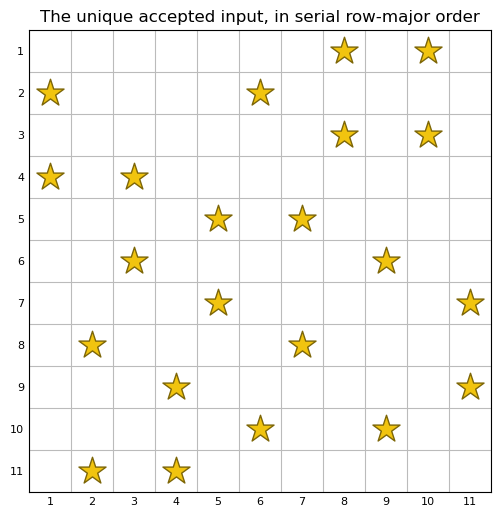

In [53]:
grid = np.array(bits).reshape(11, 11)
print('stars per row:   ', grid.sum(1))
print('stars per column:', grid.sum(0))
print('adjacent star pairs:', sum(
    grid[r, c] and grid[r + dr, c + dc]
    for r in range(11) for c in range(11)
    for dr in (-1, 0, 1) for dc in (-1, 0, 1)
    if (dr, dc) != (0, 0) and 0 <= r + dr < 11 and 0 <= c + dc < 11))
fig, ax = plt.subplots(figsize=(6, 6))
ys, xs = np.nonzero(grid)
ax.scatter(xs, ys, marker='*', s=420, c='#f1c40f', edgecolors='#7d6608')
ax.set_xticks(np.arange(-0.5, 11), minor=True); ax.set_yticks(np.arange(-0.5, 11), minor=True)
ax.grid(which='minor', color='#bbb'); ax.tick_params(which='both', length=0, labelsize=8)
ax.set_xticks(range(11), range(1, 12)); ax.set_yticks(range(11), range(1, 12))
ax.set_xlim(-0.5, 10.5); ax.set_ylim(10.5, -0.5); ax.set_aspect('equal')
ax.set_title('The unique accepted input, in serial row-major order')
plt.show()

We recover the regions from the hardware itself: flip each input bit and see which flip-flops react.

In [54]:
def probe(t):
    psim.reset(); psim.settle({'I': 0, 'enable': 0, 'rst_n': 0})
    for k in range(t): psim.edge({'I': 0, 'enable': 1, 'rst_n': 1})
    snap = list(psim.val)
    Ds = []
    for b in (0, 1):
        psim.val = list(snap)
        psim.settle({'I': b, 'enable': 1, 'rst_n': 1})
        Ds.append([psim.val[d] for q, d, *_ in pffs])
    return {i for i in range(len(pffs)) if Ds[0][i] != Ds[1][i]}

diffs = [probe(t) for t in range(121)]
where = defaultdict(list)
for t, dset in enumerate(diffs):
    for i in dset: where[i].append(t)
print('how many positions each I-sensitive flip-flop reacts at:')
print(sorted(Counter(len(ts) for ts in where.values()).items()))

how many positions each I-sensitive flip-flop reacts at:
[(4, 1), (5, 1), (6, 1), (7, 1), (8, 2), (9, 1), (11, 12), (14, 1), (21, 1), (28, 1), (110, 1), (121, 3)]


In [55]:
counters = [i for i in where if len(where[i]) < 100]
colbits = [i for i in counters if len(where[i]) == 11 and len({t % 11 for t in where[i]}) == 1]
regbits = [i for i in counters if i not in colbits]
print('input-path ffs (react almost always):', sorted(i for i in where if i not in counters))
print(len(colbits), 'bits selected by column,', len(regbits), 'bits selected irregularly')
assert all(len(dset & set(counters)) == 2 for dset in map(set, diffs))
regmap = np.full(121, -1)
for rid, i in enumerate(sorted(regbits, key=lambda i: where[i][0])):
    for t in where[i]: regmap[t] = rid
R = regmap.reshape(11, 11)
print('region sizes:', np.bincount(regmap), '| unassigned cells:', int((regmap < 0).sum()))
print(R)
def contiguous(k):
    cells = {(r, c) for r in range(11) for c in range(11) if R[r, c] == k}
    seen, stack = set(), [next(iter(cells))]
    while stack:
        p = stack.pop()
        if p in seen or p not in cells: continue
        seen.add(p)
        stack += [(p[0] + 1, p[1]), (p[0] - 1, p[1]), (p[0], p[1] + 1), (p[0], p[1] - 1)]
    return len(seen) == len(cells)
print('all regions contiguous:', all(contiguous(k) for k in range(11)),
      '| stars per region:', [int(grid[R == k].sum()) for k in range(11)])

input-path ffs (react almost always): [42, 50, 64, 68]
11 bits selected by column, 11 bits selected irregularly
region sizes: [14 21  7  5 28  8 11  9  6  8  4] | unassigned cells: 0
[[ 0  0  0  0  0  1  1  2  3  3  4]
 [ 0  0  5  0  0  1  2  2  3  3  4]
 [ 0  0  5  1  1  1  1  2  2  3  4]
 [ 0  0  5  1  6  6  6  4  2  2  4]
 [ 5  0  5  1  6  4  4  4  4  4  4]
 [ 5  5  5  1  6  6  6  4  7  7  7]
 [ 1  1  1  1  1  1  6  4  7  8  8]
 [ 1  9  9  9  6  6  6  4  7  8  8]
 [ 1  9  9 10  4  4  4  4  7  8  8]
 [ 1  1  9 10 10  4  4  4  7  7  7]
 [ 1  9  9 10  4  4  4  4  4  4  4]]
all regions contiguous: True | stars per region: [2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]


Counting to two takes two bits. We flip a low bit's stored value and see which flip-flop catches the carry.

In [56]:
inpath = [i for i in where if i not in counters]
def carry_of(i):
    t = where[i][0]
    psim.reset(); psim.settle({'I': 0, 'enable': 0, 'rst_n': 0})
    for k in range(t): psim.edge({'I': 0, 'enable': 1, 'rst_n': 1})
    snap = list(psim.val)
    Ds = []
    for v in (0, 1):
        psim.val = list(snap)
        psim.val[pffs[i][0]] = v
        psim.settle({'I': 1, 'enable': 1, 'rst_n': 1})
        Ds.append([psim.val[d] for q, d, *_ in pffs])
    return {j for j in range(len(pffs)) if Ds[0][j] != Ds[1][j]} - {i} - set(counters) - set(inpath)

high = {i: carry_of(i) for i in counters}
shared = set.intersection(*high.values()) if all(high.values()) else set()
high = {i: js - shared for i, js in high.items()}
assert all(len(js) == 1 for js in high.values()) and len(set.union(*high.values())) == 22
high = {i: js.pop() for i, js in high.items()}
print('every low bit has exactly one carry target - 22 two-bit counters')
for lab, grp in (('column', colbits), ('region', regbits)):
    print(f'{lab} low+high pairs:', ' '.join(f'{i}+{high[i]}' for i in sorted(grp)))

every low bit has exactly one carry target - 22 two-bit counters
column low+high pairs: 7+21 9+23 11+26 12+20 13+17 14+19 15+18 16+24 22+8 25+10 27+30
region low+high pairs: 31+28 32+29 33+35 34+81 82+88 83+87 84+78 85+80 86+79 90+89 91+77


Columns and regions each received a counter bank, yet nothing counted rows. Because the bits arrive row by row, a single counter can serve every row provided it resets at each boundary. We feed two stars into the first row and watch.

In [57]:
def rowtrace(stars):
    psim.reset(); psim.settle({'I': 0, 'enable': 0, 'rst_n': 0})
    M = []
    for t in range(22):
        psim.edge({'I': int(t in stars), 'enable': 1, 'rst_n': 1})
        M.append([psim.val[q] for q, *_ in pffs])
    return np.array(M)

one, two = rowtrace({0}), rowtrace({0, 5})
rlow = [i for i in inpath if one[:10, i].all() and not one[10, i]]
rhigh = [j for j in range(len(pffs)) if not one[:, j].any() and two[5:10, j].all() and not two[10, j]]
assert len(rlow) == 1 and len(rhigh) == 1
rlow, rhigh = rlow[0], rhigh[0]
assert rhigh not in counters and rhigh not in set(high.values())
pipe = sorted(set(inpath) - {rlow})
print(f'one star fed at edge 0: ff {rlow} rises and holds until the last cell of the row is clocked in')
print(f'two stars, edges 0 and 5: ff {rhigh} rises on the second and clears at the same boundary')
print('a single 2-bit counter, reset every 11 edges, checks all 11 rows in turn')

one star fed at edge 0: ff 64 rises and holds until the last cell of the row is clocked in
two stars, edges 0 and 5: ff 62 rises on the second and clears at the same boundary
a single 2-bit counter, reset every 11 edges, checks all 11 rows in turn


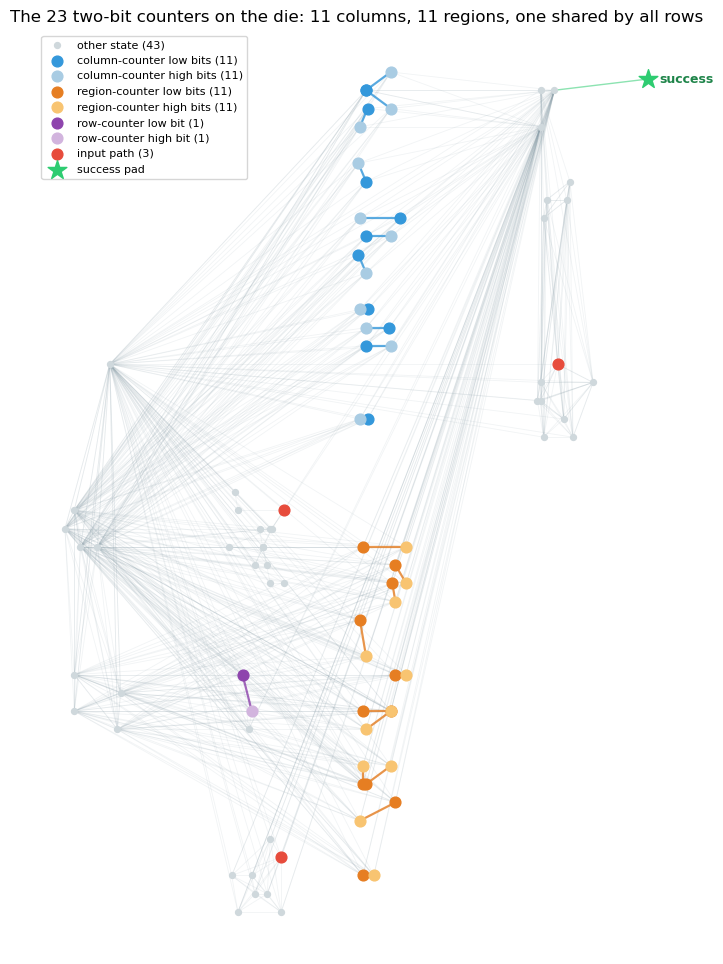

In [58]:
cls = np.zeros(len(pffs))
for i in colbits: cls[i], cls[high[i]] = 1, 4
for i in regbits: cls[i], cls[high[i]] = 2, 5
for i in pipe: cls[i] = 3
cls[rlow], cls[rhigh] = 6, 7
fig, ax = plt.subplots(figsize=(9, 12))
for i, srcs in enumerate(deps):
    for jj in srcs:
        ax.plot(*zip(pffpos[jj], pffpos[i]), color='#90a4ae', alpha=0.12, lw=0.6, zorder=1)
for i in counters:
    ax.plot(*zip(pffpos[i], pffpos[high[i]]),
            color='#3498db' if i in colbits else '#e67e22', alpha=0.8, lw=1.6, zorder=2)
ax.plot(*zip(pffpos[rlow], pffpos[rhigh]), color='#8e44ad', alpha=0.8, lw=1.6, zorder=2)
for i in sorted(ff_sources(pports['success'])):
    ax.plot(*zip(pffpos[i], sxy), color='#2ecc71', alpha=0.55, lw=1.0, zorder=2)
sty = {0: ('#cfd8dc', 'other state', 18),
       1: ('#3498db', 'column-counter low bits', 60),
       4: ('#a9cce3', 'column-counter high bits', 60),
       2: ('#e67e22', 'region-counter low bits', 60),
       5: ('#f8c471', 'region-counter high bits', 60),
       6: ('#8e44ad', 'row-counter low bit', 60),
       7: ('#d2b4de', 'row-counter high bit', 60),
       3: ('#e74c3c', 'input path', 60)}
for k, (color, lab, sz) in sty.items():
    m = cls == k
    ax.scatter(*pffpos[m].T, s=sz, c=color, label=f'{lab} ({int(m.sum())})', zorder=3)
ax.scatter(*sxy, s=200, c='#2ecc71', marker='*', zorder=5, label='success pad')
ax.annotate('success', sxy, textcoords='offset points', xytext=(8, -3),
            fontsize=9, color='#1e8449', fontweight='bold')
ax.set_aspect('equal'); ax.set_axis_off(); ax.legend(loc='upper left', fontsize=8)
ax.set_title('The 23 two-bit counters on the die: 11 columns, 11 regions, one shared by all rows')
plt.show()

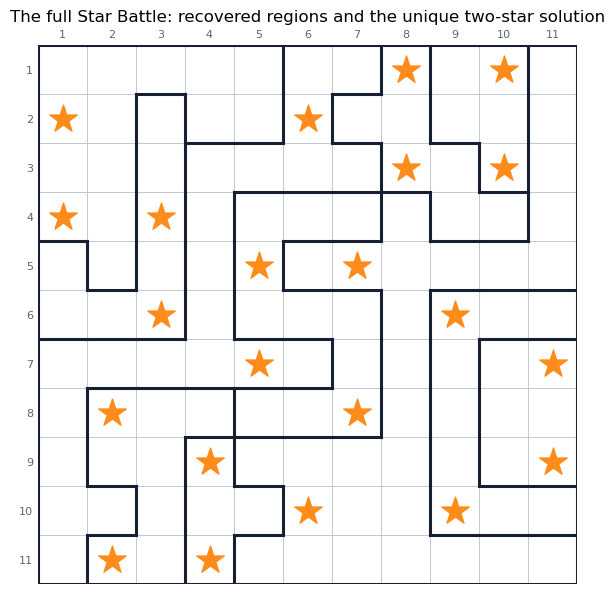

In [59]:
fig, ax = plt.subplots(figsize=(7, 7))
for k in range(12):
    ax.plot([-0.5, 10.5], [k - 0.5, k - 0.5], color='#b9c0cc', lw=0.6, zorder=1)
    ax.plot([k - 0.5, k - 0.5], [-0.5, 10.5], color='#b9c0cc', lw=0.6, zorder=1)
for r in range(11):
    for c in range(11):
        if c + 1 < 11 and R[r, c] != R[r, c + 1]:
            ax.plot([c + 0.5, c + 0.5], [r - 0.5, r + 0.5], color='#172033', lw=2.2, zorder=2)
        if r + 1 < 11 and R[r, c] != R[r + 1, c]:
            ax.plot([c - 0.5, c + 0.5], [r + 0.5, r + 0.5], color='#172033', lw=2.2, zorder=2)
ax.add_patch(plt.Rectangle((-0.5, -0.5), 11, 11, fill=False, edgecolor='#172033', lw=2.2, zorder=2))
ys, xs = np.nonzero(grid)
ax.scatter(xs, ys, marker='*', s=430, c='#ff8c1a', zorder=3)
ax.set_xticks(range(11), range(1, 12)); ax.set_yticks(range(11), range(1, 12))
ax.tick_params(length=0, labelsize=8, labelcolor='#5b6472', labeltop=True, labelbottom=False)
for s in ax.spines.values(): s.set_visible(False)
ax.set_xlim(-0.5, 10.5); ax.set_ylim(10.5, -0.5)
ax.set_aspect('equal')
ax.set_title('The full Star Battle: recovered regions and the unique two-star solution')
plt.show()